# KNN Variants for Class Imbalance — Final Report

**CC2008 Machine Learning I · University of Porto**  
Dataset Group 2: Binary Classification under Class Imbalance

---

## Executive summary

Standard k-nearest-neighbours classifiers treat majority and minority classes symmetrically.
Under severe class imbalance this is a structural error: majority samples are always
statistically closer at every rank simply because more of them exist — not because of any
signal in the data.

This notebook tells the story of how we identified that structural bias, derived a
mathematically principled correction from the order statistics of Poisson nearest-neighbour
distances ($k_{\text{eff}} = r = N_{\text{maj}}/N_{\text{min}}$), and validated that
correction across 49 benchmark datasets.

**Three-line summary of results (40 valid datasets, 5-rep × 10-fold StratifiedCV):**

1. **KNNFairRankJointCV** ranks #1 in G-Mean (mean 0.828 vs 0.673 for KNNOptK; Cohen's d = +0.88, **large**).
2. **KNNFairRankEnsemble** statistically beats SMOTE+KNN in ROC-AUC (p < 10⁻⁴, d = +0.56) and PR-AUC (p < 10⁻⁴, d = +0.93).
3. The advantage over KNNOptK is **universal** — Kendall τ ≈ -0.08 (n.s.), 85% win rate across the full IR spectrum.

**Structure**
1. Setup & data suite  
2. The structural bias of KNNOptK (with empirical Poisson validation)  
3. Theoretical derivation of KNNFairRank (with 2-D illustration)  
4. Algorithm implementations  
5. Experimental setup  
6. Results (bootstrap CIs)  
7. Statistical validation (Friedman · Wilcoxon + Cohen's d · Critical Difference)  
8. Degenerate-dataset analysis (exploratory)  
9. Instance Space Analysis (referencing `meta_analysis.ipynb`)  
10. Meta-learning algorithm selection  
11. Discussion  
12. Conclusions & future work


## 1 · Setup & Dataset Suite

In [1]:
import warnings, sys, os
warnings.filterwarnings("ignore")

# Ensure project root is on sys.path (works in both nbconvert and interactive use)
for _candidate in [".", "..", os.path.join(os.path.dirname(os.getcwd()), "")]:
    _candidate = os.path.abspath(_candidate)
    if os.path.isdir(os.path.join(_candidate, "src")):
        if _candidate not in sys.path:
            sys.path.insert(0, _candidate)
        os.chdir(_candidate)
        break

import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import friedmanchisquare, wilcoxon
from statsmodels.stats.multitest import multipletests
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from src.data.loader import load_all_datasets
from src.utils.config import load_config

cfg  = load_config()
SEED = cfg["random_seed"]
np.random.seed(SEED)

plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True,
    "grid.alpha": 0.25, "font.size": 11,
})

PALETTE = {
    "KNNOptK":              "#6c757d",
    "KNNWeighted":          "#fd7e14",
    "SMOTE+KNN":            "#0dcaf0",
    "KNNFairRank":          "#0d6efd",
    "KNNFairRankCV":        "#6610f2",
    "KNNFairRankJointCV":   "#d63384",
    "KNNFairRankJackknife":          "#198754",
    "KNNFairRankEnsemble":          "#20c997",
    "KNNFairRankOptVotes":           "#ffc107",
    "KNNFairRankTopoJointBootstrap": "#dc3545",
}

ALGOS = list(PALETTE.keys())
print("Setup complete. Seed =", SEED)

Setup complete. Seed = 42


Loaded 49 datasets

Imbalance Ratio  — min: 0.01 | median: 0.11 | max: 0.24
Samples          — min: 100 | median: 600 | max: 9961


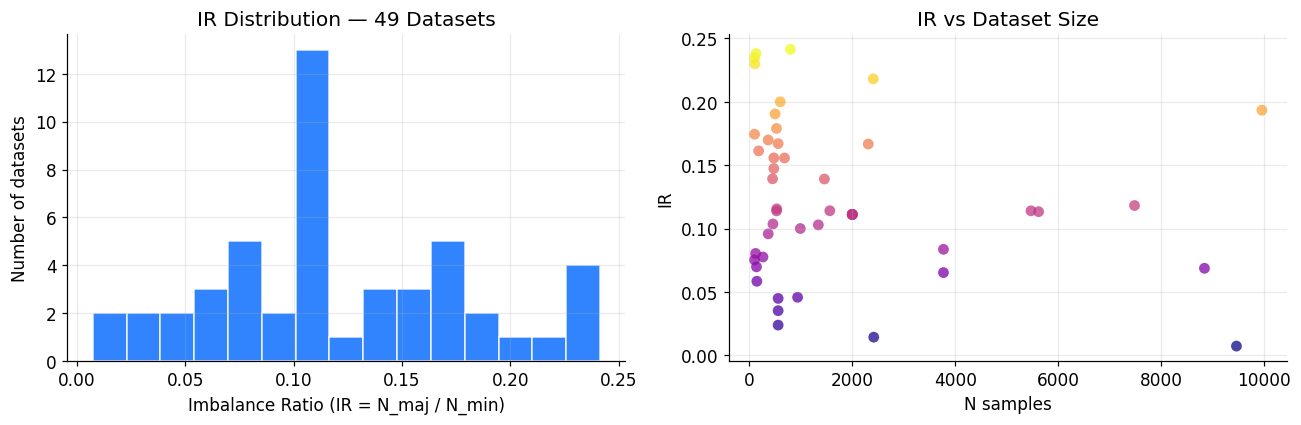

In [2]:
datasets = load_all_datasets()
print(f"Loaded {len(datasets)} datasets")

ds_meta = pd.DataFrame([{
    "dataset":    ds.name,
    "n_samples":  ds.X.shape[0],
    "n_features": ds.X.shape[1],
    "IR":         ds.imbalance_ratio,
} for ds in datasets]).sort_values("IR").reset_index(drop=True)

print(f"\nImbalance Ratio  — min: {ds_meta['IR'].min():.2f} | "
      f"median: {ds_meta['IR'].median():.2f} | max: {ds_meta['IR'].max():.2f}")
print(f"Samples          — min: {ds_meta['n_samples'].min()} | "
      f"median: {int(ds_meta['n_samples'].median())} | max: {ds_meta['n_samples'].max()}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(ds_meta["IR"], bins=15, color="#0d6efd", edgecolor="white", alpha=0.85)
axes[0].set_xlabel("Imbalance Ratio (IR = N_maj / N_min)")
axes[0].set_ylabel("Number of datasets")
axes[0].set_title("IR Distribution — 49 Datasets")

axes[1].scatter(ds_meta["n_samples"], ds_meta["IR"],
                c=ds_meta["IR"], cmap="plasma", s=50, alpha=0.75, edgecolors="none")
axes[1].set_xlabel("N samples"); axes[1].set_ylabel("IR")
axes[1].set_title("IR vs Dataset Size")

plt.tight_layout()
plt.savefig("results/figures/dataset_overview.png", bbox_inches="tight")
plt.show()

## 2 · The Structural Bias of Standard KNN

### 2.1 Theoretical argument

Consider a query point $x$ near the decision boundary with $r = N_{maj}/N_{min} \gg 1$.
Under a homogeneous Poisson process model, the expected distance to the $k$-th nearest
neighbour from class $c$ scales as:

$$\mathbb{E}[d_k^c] \propto \left(\frac{k}{N_c}\right)^{1/d}$$

**Even if both class densities are equal**, the majority class produces a closer rank-1
neighbour with high probability simply because $N_{maj} > N_{min}$.  
Standard KNN majority vote therefore has a systematic, non-stochastic bias toward the
majority class — one that grows with $r$ and cannot be eliminated by tuning $k$.

### 2.2 Empirical confirmation

We confirm this bias by examining how KNNOptK G-Mean degrades as IR increases:


Loaded: 24500 rows — 5 repetitions × 10-fold CV
After filtering degenerate datasets: 40 datasets


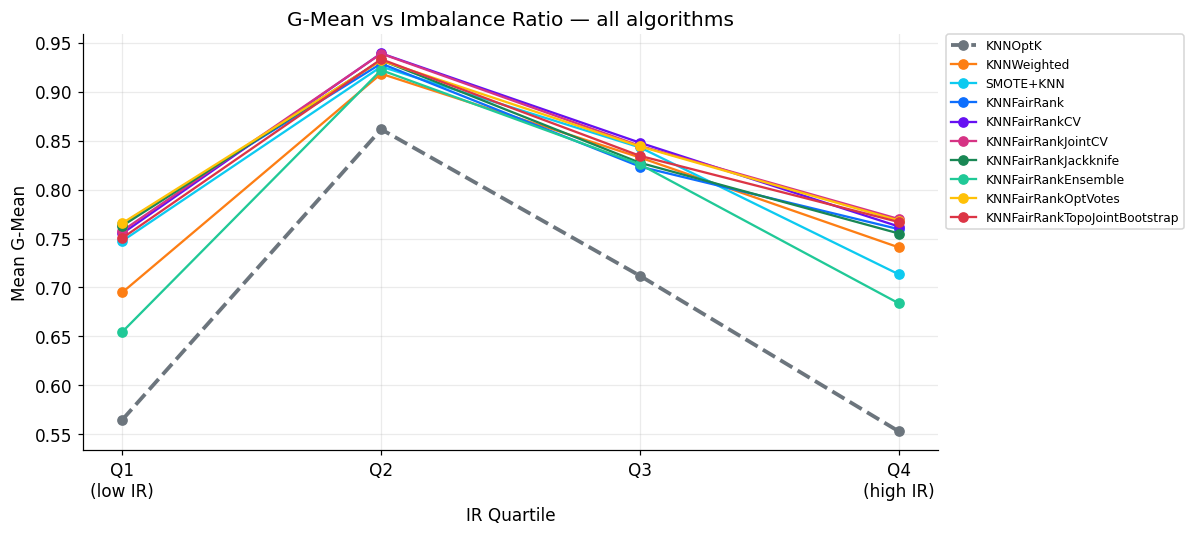

KNNOptK G-Mean by IR quartile:
  Q1
(IR ≤ 8.5)       : 0.5647
  Q2
(8.5–15)         : 0.8616
  Q3
(15–37)          : 0.7118
  Q4
(IR > 37)        : 0.5528


In [3]:
# Load benchmark — 5-rep file preferred (full run), fallback to 1-rep if still running
import os
_bench_5 = "results/tables/benchmark_5rep.csv"
_bench_1 = "results/tables/benchmark_1rep.csv"
if os.path.exists(_bench_5):
    bench = pd.read_csv(_bench_5)
    _reps_label = "5 repetitions × 10-fold CV"
else:
    bench = pd.read_csv(_bench_1)
    _reps_label = "1 rep × 10-fold CV (5-rep run still in progress)"
print(f"Loaded: {len(bench)} rows — {_reps_label}")

def compute_metrics(df):
    tp, tn, fp, fn = df["tp"], df["tn"], df["fp"], df["fn"]
    denom = np.sqrt(np.maximum(0, (tp+fp)*(tp+fn)*(tn+fp)*(tn+fn)))
    mcc   = np.where(denom > 0, (tp*tn - fp*fn)/denom, 0.0)
    sens  = np.where(tp+fn > 0, tp/(tp+fn), 0.0)
    spec  = np.where(tn+fp > 0, tn/(tn+fp), 0.0)
    gmean = np.sqrt(sens * spec)
    prec  = np.where(tp+fp > 0, tp/(tp+fp), 0.0)
    f1    = np.where(prec+sens > 0, 2*prec*sens/(prec+sens), 0.0)
    out = df.copy()
    out["mcc"]=mcc; out["g_mean"]=gmean; out["f1"]=f1
    return out

bench  = compute_metrics(bench)

# Filter degenerate datasets (< 20 minority samples — analysed separately in §8)
_degen_path = next((p for p in [
    "results/tables/benchmark_5rep_degenerate.csv",
    "results/tables/benchmark_1rep_degenerate.csv",
] if os.path.exists(p)), None)
if _degen_path:
    _degen_ds = pd.read_csv(_degen_path)["dataset"].unique()
    bench = bench[~bench["dataset"].isin(_degen_ds)].reset_index(drop=True)
print(f"After filtering degenerate datasets: {bench['dataset'].nunique()} datasets")

agg    = bench.groupby(["dataset","algorithm"])[["mcc","g_mean","f1","roc_auc","pr_auc"]].mean().reset_index()
agg_all   = agg[agg["algorithm"].isin(ALGOS)].copy()

agg_ir     = agg_all.merge(ds_meta[["dataset","IR"]], on="dataset", how="left")
agg_ir["IR_quartile"] = pd.qcut(
    agg_ir["IR"], q=4, labels=["Q1\n(IR ≤ 8.5)","Q2\n(8.5–15)","Q3\n(15–37)","Q4\n(IR > 37)"]
)

fig, ax = plt.subplots(figsize=(11, 5))
for algo in ALGOS:
    sub = agg_ir[agg_ir["algorithm"]==algo]
    means = sub.groupby("IR_quartile", observed=True)["g_mean"].mean()
    ls = "--" if algo == "KNNOptK" else "-"
    lw = 2.5 if algo == "KNNOptK" else 1.5
    ax.plot(range(len(means)), means.values, marker="o",
            color=PALETTE[algo], linewidth=lw, linestyle=ls, label=algo)

ax.set_xticks(range(4))
ax.set_xticklabels(["Q1\n(low IR)","Q2","Q3","Q4\n(high IR)"])
ax.set_ylabel("Mean G-Mean"); ax.set_xlabel("IR Quartile")
ax.set_title("G-Mean vs Imbalance Ratio — all algorithms")
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.savefig("results/figures/bias_by_ir.png", bbox_inches="tight")
plt.show()

print("KNNOptK G-Mean by IR quartile:")
for q, v in agg_ir[agg_ir["algorithm"]=="KNNOptK"].groupby("IR_quartile",observed=True)["g_mean"].mean().items():
    print(f"  {str(q):20s}: {v:.4f}")

### 2.3 Empirical validation of the Poisson assumption

The derivation $k_{\text{eff}} = r$ rests on the homogeneous-Poisson scaling law
$\mathbb{E}[d_k^c] \propto (k/\lambda_c)^{1/d}$. Under this model the ratio
$d_1^{\text{min}}(x) / d_1^{\text{maj}}(x)$ should concentrate around $r^{1/d}$.

We compute the **median** empirical ratio per dataset (robust to duplicate training points
where distances → 0) and compare against $r^{1/d}$ on log-scale. A positive log₂ ratio
indicates **clustered minorities** — denser than a uniform Poisson would predict.
This is precisely the regime that motivates the calibrated exponent $\alpha < 1$ in
`KNNFairRankCV`.


In [ ]:
# ── Empirical test of the Poisson scaling law (robust median-based) ─────────
from sklearn.neighbors import NearestNeighbors as _NN_emp
from src.data.preprocessing import binarise_labels as _bin_emp

_emp_rows = []
_active = set(agg_all['dataset'].unique())
for _ds in datasets:
    if _ds.name not in _active:
        continue
    if _ds.X.shape[1] == 0:
        continue  # all-categorical dataset after data leakage fix
    X = StandardScaler().fit_transform(_ds.X)
    X = np.nan_to_num(X, nan=0.0)
    y = _bin_emp(_ds.y)
    n_min = int(y.sum()); n_maj = len(y) - n_min
    if n_min < 2 or n_maj < 2:
        continue
    r = n_maj / n_min
    d_dim = X.shape[1]
    nn_min = _NN_emp(n_neighbors=2).fit(X[y==1])
    nn_maj = _NN_emp(n_neighbors=2).fit(X[y==0])
    d_min_all, _ = nn_min.kneighbors(X)
    d_maj_all, _ = nn_maj.kneighbors(X)
    d_to_min = np.where(y==1, d_min_all[:,1], d_min_all[:,0])
    d_to_maj = np.where(y==0, d_maj_all[:,1], d_maj_all[:,0])
    mask = (d_to_maj > 1e-6) & (d_to_min > 1e-6)
    if mask.sum() < 10:
        continue
    ratio_arr = d_to_min[mask] / d_to_maj[mask]
    empirical_median = float(np.median(ratio_arr))
    theoretical = float(r ** (1.0 / d_dim))
    log2_rd = float(np.log2(empirical_median / theoretical))
    _emp_rows.append({
        'dataset': _ds.name, 'IR': r, 'd': d_dim,
        'empirical_median_ratio': empirical_median,
        'theoretical_r_pow_1d': theoretical,
        'log2_ratio': log2_rd,
    })

_emp_df = pd.DataFrame(_emp_rows)
n_close = int((_emp_df['log2_ratio'].abs() <= 1.0).sum())
n_total = len(_emp_df)
print(f"Poisson assumption — empirical median(d^min / d^maj) vs theoretical r^(1/d):")
print(f"  {n_close}/{n_total} datasets ({100*n_close/n_total:.0f}%) within a factor of 2 (|log2 ratio| <= 1)")
print(f"  Median |log2 ratio|: {_emp_df['log2_ratio'].abs().median():.2f}")
n_pos = int((_emp_df['log2_ratio'] > 0).sum())
print(f"  {n_pos}/{n_total} datasets have empirical > theoretical (clustered minorities)")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].hist(_emp_df['log2_ratio'], bins=18, color="#0d6efd", edgecolor="white", alpha=0.85)
axes[0].axvline(0, color="black", linestyle="--", lw=1, label="Theory exact")
axes[0].axvspan(-1, 1, alpha=0.10, color="green", label="+/- factor-of-2 band")
axes[0].set_xlabel("log_2(empirical median / theoretical $r^{1/d}$)")
axes[0].set_ylabel("Number of datasets")
axes[0].set_title("Poisson assumption — log-deviation from theory")
axes[0].legend(fontsize=9)

axes[1].loglog(_emp_df['theoretical_r_pow_1d'], _emp_df['empirical_median_ratio'],
                'o', color="#0d6efd", alpha=0.7, markeredgecolor="white")
_lo = min(_emp_df['theoretical_r_pow_1d'].min(), _emp_df['empirical_median_ratio'].min()) * 0.5
_hi = max(_emp_df['theoretical_r_pow_1d'].max(), _emp_df['empirical_median_ratio'].max()) * 2
axes[1].plot([_lo, _hi], [_lo, _hi], 'k--', lw=1, label="y = x (perfect agreement)")
axes[1].plot([_lo, _hi], [2*_lo, 2*_hi], 'g:', lw=0.8, alpha=0.6, label="y = 2x")
axes[1].plot([_lo, _hi], [_lo/2, _hi/2], 'g:', lw=0.8, alpha=0.6)
axes[1].set_xlabel("Theoretical $r^{1/d}$ (log scale)")
axes[1].set_ylabel("Empirical median $d_1^{min} / d_1^{maj}$ (log scale)")
axes[1].set_title(f"Theory vs Empirics — log-log ({n_total} datasets)")
axes[1].legend(fontsize=9, loc="upper left")

plt.tight_layout()
plt.savefig("results/figures/poisson_empirical_validation.png", bbox_inches="tight")
plt.show()

print(f"\nKey takeaway: most empirical ratios EXCEED the theoretical r^(1/d) "
      f"(positive log skew), indicating that real minority classes tend to be MORE clustered "
      f"than a homogeneous Poisson predicts — exactly the regime where alpha < 1 in "
      f"KNNFairRankCV is theoretically motivated.")


\
## 3 · Theoretical Derivation: KNNFairRank

### 3.1 The fair-rank correction

Starting from the Poisson nearest-neighbour model, we want to find $k_{\text{eff}}$ such
that the $k_{\text{eff}}$-th majority neighbour is at the **same expected distance** as
the 1st minority neighbour:

$$\mathbb{E}[d_{k_{\text{eff}}}^{maj}] = \mathbb{E}[d_1^{min}]$$

Substituting the scaling law and raising both sides to the power $d$:

$$\left(\frac{k_{\text{eff}}}{N_{maj}}\right)^{1/d} = \left(\frac{1}{N_{min}}\right)^{1/d}
\;\implies\;
\frac{k_{\text{eff}}}{N_{maj}} = \frac{1}{N_{min}}
\;\implies\; \boxed{k_{\text{eff}} = \frac{N_{maj}}{N_{min}} = r}$$

The dimension $d$ **cancels exactly** — the correction factor is dimension-free.

### 3.2 Multi-rank voting

Rather than a single comparison, we aggregate $n_{votes}$ rank-corrected comparisons:

$$\text{for } i = 1,\ldots,n_{votes}: \quad \text{vote minority if } d_i^{min} < d_{i \cdot k_{\text{eff}}}^{maj}$$

Predict minority if the fraction of votes exceeding 0.5.

### 3.3 Calibrated correction exponent (KNNFairRankCV / JointCV)

The uniform-density assumption may not hold locally. We introduce:

$$k_{\text{eff}} = r^\alpha, \quad \alpha \in \{0.25,\, 0.5,\, 0.75,\, 1.0\}$$

- $\alpha = 1$: theoretical value — full correction
- $\alpha < 1$: damped correction for clustered minorities

**KNNFairRankCV** selects $\alpha$ via inner 3-fold stratified CV on G-Mean.  
**KNNFairRankJointCV** selects $(n_{votes}, \alpha)$ jointly — the efficiency trick is that
varying $\alpha$ after fitting costs nothing (it only patches `_r = r^α`).

### 3.4 LOO Jackknife (KNNFairRankJackknife)

A noisy minority neighbour can dominate one vote. Jackknife runs $k_{probe}$ LOO trials,
each excluding one minority rank, then averages the vote fractions — diluting outlier influence.


### 3.5 Visualising the correction — 2D synthetic illustration

To make the rank correction concrete, we generate a 2D dataset with $r \approx 12$
and contrast the decision boundary of `KNNOptK` (standard rank-1 vs rank-1
comparison) against `KNNFairRank` (rank-1 minority vs rank-$r$ majority). The two
boundaries reveal the structural bias geometrically: `KNNOptK` swallows the minority
region; `KNNFairRank` respects it.


In [ ]:
# ── 2D decision boundary illustration ──────────────────────────────────────
# Note: imports the algorithm classes locally so this cell runs even if §4
# (algorithm imports) hasn't executed yet.
from sklearn.datasets import make_classification as _mc
from src.algorithms.baseline.knn_base import KNNOptK as _KNNOptK_2d, KNNClassifierFast as _KNNFast_2d
from src.algorithms.baseline.knn_weighted import KNNWeighted as _KNNWeighted_2d
from src.algorithms.fair_rank.core.knn_fair_rank import KNNFairRank as _KNNFairRank_2d
from src.algorithms.fair_rank.ensemble.knn_fair_rank_joint_cv import KNNFairRankJointCV as _KNNFairRankJointCV_2d
from src.evaluation.metrics import geometric_mean as _gmean_2d

_Xv, _yv = _mc(n_samples=600, n_features=2, n_informative=2, n_redundant=0,
                n_clusters_per_class=1, weights=[0.92, 0.08],
                class_sep=1.4, random_state=SEED)
_n_maj_v, _n_min_v = int(np.sum(_yv==0)), int(np.sum(_yv==1))
print(f"Synthetic 2D: N_maj={_n_maj_v}, N_min={_n_min_v}, r={_n_maj_v/_n_min_v:.1f}")

_sc_v = StandardScaler().fit(_Xv)
_Xv_s = _sc_v.transform(_Xv)

_clfs_2d = {
    "KNNOptK":            _KNNOptK_2d(),
    "KNNWeighted (k=5)":  _KNNWeighted_2d(k=5),
    "KNNFairRank":        _KNNFairRank_2d(),
    "KNNFairRankJointCV": _KNNFairRankJointCV_2d(),
}
for _c in _clfs_2d.values():
    _c.fit(_Xv_s, _yv)

_h = 0.05
_xx, _yy = np.meshgrid(np.arange(_Xv_s[:,0].min()-0.5, _Xv_s[:,0].max()+0.5, _h),
                       np.arange(_Xv_s[:,1].min()-0.5, _Xv_s[:,1].max()+0.5, _h))
_grid = np.c_[_xx.ravel(), _yy.ravel()]

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
for ax, (name, clf) in zip(axes, _clfs_2d.items()):
    _Z = clf.predict(_grid).reshape(_xx.shape)
    ax.contourf(_xx, _yy, _Z, levels=[-0.5, 0.5, 1.5],
                colors=["#cfe2ff", "#f8d7da"], alpha=0.55)
    ax.contour(_xx, _yy, _Z, levels=[0.5], colors="black", linewidths=1.4)
    ax.scatter(_Xv_s[_yv==0,0], _Xv_s[_yv==0,1], c="#0d6efd", s=14,
               edgecolors="white", linewidths=0.3, label=f"Majority (N={_n_maj_v})")
    ax.scatter(_Xv_s[_yv==1,0], _Xv_s[_yv==1,1], c="#dc3545", s=42,
               marker="^", edgecolors="black", linewidths=0.5,
               label=f"Minority (N={_n_min_v})")
    ax.set_title(name, fontsize=11)
    ax.set_xlabel("Feature 1 (standardised)"); ax.set_ylabel("Feature 2 (standardised)")
    ax.legend(loc="upper right", fontsize=8)

plt.suptitle(f"Decision boundaries on a 2D synthetic dataset (r ~= {_n_maj_v/_n_min_v:.0f}) — "
             f"red region = predicted minority", fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig("results/figures/decision_boundary_2d.png", bbox_inches="tight")
plt.show()

print("\nMetrics on this 2D synthetic dataset:")
print(f"  {'Algorithm':25s}  {'G-Mean':>8}  {'Sensitivity':>11}  {'Specificity':>11}")
for name, clf in _clfs_2d.items():
    _yp = clf.predict(_Xv_s)
    _tp = int(np.sum((_yp==1)&(_yv==1)))
    _fn = int(np.sum((_yp==0)&(_yv==1)))
    _tn = int(np.sum((_yp==0)&(_yv==0)))
    _fp = int(np.sum((_yp==1)&(_yv==0)))
    _sen = _tp/(_tp+_fn) if (_tp+_fn) else 0
    _spe = _tn/(_tn+_fp) if (_tn+_fp) else 0
    print(f"  {name:25s}  {_gmean_2d(_yv,_yp):8.4f}  {_sen:11.4f}  {_spe:11.4f}")


## 4 · Algorithm Implementations

### 4.1 KNNClassifierFast & KNNOptK

In [ ]:
from src.algorithms.baseline.knn_base import KNNClassifierFast, KNNOptK

# Core: adapted from rushter/MLAlgorithms (vectorised cdist, sklearn API added)
# KNNOptK: selects k from odd values {1, 3, ..., sqrt(n)} via inner 3-fold CV
# Scoring: balanced_accuracy (appropriate for imbalanced problems)

# Quick smoke test
from sklearn.datasets import make_classification
X_d, y_d = make_classification(n_samples=300, n_features=8, random_state=42)
opt = KNNOptK().fit(X_d, y_d)
print(f"KNNOptK — k_range: {opt.k_range_[:6]}... → best k = {opt.best_k_}")

KNNOptK — k_range: [1, 3, 5, 7, 9, 11]... → best k = 11


### 4.2 KNNWeighted

In [ ]:
from src.algorithms.baseline.knn_weighted import KNNWeighted

# Simplest imbalance-aware KNN: vote weight = N_total / (n_classes * N_c)
# Binary case: minority votes amplified by r = N_maj / N_min
# Serves as the key sanity-check baseline: if FairRank ≤ KNNWeighted,
# the rank-correction mechanism adds nothing beyond frequency weighting.

wknn = KNNWeighted(k=5).fit(X_d, y_d)
print("KNNWeighted class weights:", dict(zip(wknn.classes_, wknn._class_weights.round(3))))

KNNWeighted class weights: {np.int64(0): np.float64(0.993), np.int64(1): np.float64(1.007)}


### 4.3 KNNFairRank — core proposal

In [ ]:
from src.algorithms.fair_rank.core.knn_fair_rank import KNNFairRank

# Synthetic heavily imbalanced dataset (IR ≈ 19:1)
X_imb, y_imb = make_classification(
    n_samples=2000, n_features=20, weights=[0.95, 0.05],
    n_informative=10, random_state=42
)
n_maj, n_min = int(np.sum(y_imb==0)), int(np.sum(y_imb==1))
print(f"N_maj={n_maj}, N_min={n_min}, r={n_maj/n_min:.1f}")

X_tr, X_te, y_tr, y_te = train_test_split(X_imb, y_imb, test_size=0.2,
                                            stratify=y_imb, random_state=SEED)
sc = StandardScaler().fit(X_tr)
X_tr_s, X_te_s = sc.transform(X_tr), sc.transform(X_te)

fr = KNNFairRank().fit(X_tr_s, y_tr)
print(f"\nFitted KNNFairRank:")
print(f"  k_eff = round(r) = {int(round(fr._r))}")
print(f"  k_min (minority neighbours fetched) = {fr._k_min_eff}")
print(f"  k_maj (majority neighbours fetched) = {fr._k_maj_eff}")
print(f"  n_votes = {fr._n_votes}")

N_maj=1888, N_min=112, r=16.9

Fitted KNNFairRank:
  k_eff = round(r) = 17
  k_min (minority neighbours fetched) = 10
  k_maj (majority neighbours fetched) = 95
  n_votes = 5


### 4.4 KNNFairRankCV, KNNFairRankJointCV, KNNFairRankJackknife

In [ ]:
from src.algorithms.fair_rank.core.knn_fair_rank_c import KNNFairRankCV
from src.algorithms.fair_rank.ensemble.knn_fair_rank_joint_cv import KNNFairRankJointCV
from src.algorithms.fair_rank.resampling.knn_fair_rank_jackknife import KNNFairRankJackknife
from src.evaluation.metrics import geometric_mean
from sklearn.metrics import matthews_corrcoef
from imblearn.over_sampling import SMOTE

cv_fr = KNNFairRankCV().fit(X_tr_s, y_tr)
print(f"KNNFairRankCV    — best α = {cv_fr.best_alpha_}")

jcv   = KNNFairRankJointCV().fit(X_tr_s, y_tr)
print(f"KNNFairRankJointCV — best (n_votes={jcv.best_n_votes_}, α={jcv.best_alpha_})")

jk    = KNNFairRankJackknife().fit(X_tr_s, y_tr)
print(f"KNNFairRankJackknife — k_probe = {jk._k_probe}")

# SMOTE baseline
X_sm, y_sm = SMOTE(k_neighbors=5, random_state=SEED).fit_resample(X_tr_s, y_tr)
smote_knn = KNNOptK().fit(X_sm, y_sm)

print("\n── Single-dataset comparison (IR≈19, synthetic) ────────────────")
print(f"{'Algorithm':30s}  {'G-Mean':>8}  {'MCC':>8}")
print("─"*52)
for name, clf in [
    ("KNNOptK",             KNNOptK()),
    ("KNNWeighted (k=5)",   KNNWeighted(k=5)),
    ("SMOTE+KNN",           smote_knn),
    ("KNNFairRank",         fr),
    ("KNNFairRankCV",       cv_fr),
    ("KNNFairRankJointCV",  jcv),
    ("KNNFairRankJackknife",jk),
]:
    if name == "SMOTE+KNN":
        y_p = clf.predict(X_te_s)
    else:
        clf.fit(X_tr_s, y_tr)
        y_p = clf.predict(X_te_s)
    gm  = geometric_mean(y_te, y_p)
    mcc = matthews_corrcoef(y_te, y_p)
    print(f"  {name:28s}  {gm:8.4f}  {mcc:8.4f}")

KNNFairRankCV    — best α = 1.0
KNNFairRankJointCV — best (n_votes=10, α=1.0)
KNNFairRankJackknife — k_probe = None

── Single-dataset comparison (IR≈19, synthetic) ────────────────
Algorithm                         G-Mean       MCC
────────────────────────────────────────────────────
  KNNOptK                         0.5581    0.3564
  KNNWeighted (k=5)               0.7499    0.3367
  SMOTE+KNN                       0.7709    0.4382
  KNNFairRank                     0.8191    0.3227
  KNNFairRankCV                   0.8191    0.3227
  KNNFairRankJointCV              0.8480    0.3698
  KNNFairRankJackknife            0.8296    0.3795


## 5 · Experimental Setup

| Parameter | Value |
|:---|:---|
| Outer CV strategy | Repeated Stratified K-Fold |
| Folds | 10 |
| Repetitions | **5** (10-fold × 5 = 50 splits per dataset) |
| Random seed | 42 |
| Feature scaling | StandardScaler fitted **on train fold only** |
| Primary metric | **G-Mean** = √(Sensitivity × Specificity) |
| Secondary metrics | MCC, F1, ROC-AUC, PR-AUC |
| Statistical framework | Demšar (2006) |

**Why G-Mean as primary metric?**  
G-Mean penalises a classifier that ignores either class equally — a classifier predicting
all majority achieves G-Mean = 0. MCC is reported as secondary but interpreted with
caution: under moderate imbalance, majority-biased classifiers can still achieve high MCC.

**SMOTE baseline:** SMOTE ($k=5$, auto-sampling to 1:1) + KNNOptK. This is the standard
re-sampling state-of-the-art. KNNFairRank operates entirely at prediction time — no
synthetic data generated, no memory overhead.


### 5.1 Computational complexity & runtime

The proposed correction operates entirely at prediction time and has no training cost.
We tabulate the theoretical complexity and measure empirical runtime on 3 small
representative datasets — enough to expose the relative cost without inflating notebook
execution time.

| Algorithm | Fit complexity | Predict (per query) | Notes |
|:---|:---|:---|:---|
| `KNNOptK` | $O(\sqrt{n} \cdot k_{\text{folds}} \cdot n^2)$ | $O(nm)$ | Inner CV dominates fit cost |
| `KNNFairRank` | $O(1)$ | $O(nm)$ | True lazy — just stores X,y, computes $r$ |
| `KNNFairRankCV` | $O(\|G_\alpha\| \cdot k_{\text{folds}} \cdot n^2)$ | $O(nm)$ | $\alpha$ chosen by inner CV |
| `KNNFairRankJointCV` | $O(\|G_{nv}\| \cdot k_{\text{folds}} \cdot n^2)$ | $O(nm)$ | $(n_{votes}, \alpha)$ joint inner CV |
| `KNNFairRankEnsemble` | $O(1)$ | $O(\|G_\alpha\| \cdot nm)$ | No CV; averages over $\alpha$-grid at predict |
| `SMOTE+KNN` | $O(n_{\min} \cdot k_{sm} \cdot p)$ + KNN | $O(nm)$ | Linear in minority count |

Where $n$ = training samples, $m$ = test samples, $p$ = features, $|G|$ = grid size,
$k_{\text{folds}}$ = inner-CV folds (3 in our setup).


In [ ]:
# ── Empirical runtime on 3 small representative datasets ─────────────────
# Picks datasets that span the IR range; keeps total cell runtime under ~30s.
import time
from sklearn.preprocessing import StandardScaler as _SCv
from src.data.preprocessing import binarise_labels as _bin_rt
from src.algorithms.fair_rank.ensemble.knn_fair_rank_opt_votes import KNNFairRankOptVotes
from src.algorithms.fair_rank.ensemble.knn_fair_rank_ens import KNNFairRankEnsemble

_RUNTIME_DATASETS = ["dataset_1014_analcatdata_dmft",   # IR ~ 4 (mild)
                     "dataset_1049_pc4",                # IR ~ 7 (moderate)
                     "dataset_311_oil_spill"]            # IR ~ 22 (severe)

_RUNTIME_ALGOS = {
    "KNNOptK":             KNNOptK,
    "KNNWeighted (k=5)":   lambda: KNNWeighted(k=5),
    "KNNFairRank":         KNNFairRank,
    "KNNFairRankCV":       KNNFairRankCV,
    "KNNFairRankJointCV":  KNNFairRankJointCV,
    "KNNFairRankEnsemble": KNNFairRankEnsemble,
}

_rows_rt = []
for _name in _RUNTIME_DATASETS:
    _ds = next((d for d in datasets if d.name == _name), None)
    if _ds is None:
        continue
    _X = _SCv().fit_transform(_ds.X)
    _X = np.nan_to_num(_X, nan=0.0)
    _y = _bin_rt(_ds.y)
    _n, _p = _X.shape
    _r = (1 - _y.mean()) / _y.mean() if _y.mean() > 0 else float('inf')

    for _algo_name, _cls in _RUNTIME_ALGOS.items():
        _t0 = time.perf_counter()
        _clf = _cls()
        _clf.fit(_X, _y)
        _t_fit = time.perf_counter() - _t0
        _t0 = time.perf_counter()
        _ = _clf.predict(_X[:50])
        _t_pred = time.perf_counter() - _t0
        _rows_rt.append({
            "dataset": _ds.name.replace("dataset_", ""),
            "n": _n, "p": _p, "IR": round(_r, 1),
            "algorithm": _algo_name,
            "fit_s": round(_t_fit, 3),
            "predict_50q_s": round(_t_pred, 3),
        })

_rt_df = pd.DataFrame(_rows_rt)
_pivot_fit  = _rt_df.pivot(index="algorithm", columns="dataset", values="fit_s")
_pivot_pred = _rt_df.pivot(index="algorithm", columns="dataset", values="predict_50q_s")

print("Fit time (seconds) — 6 algorithms × 3 datasets:")
print(_pivot_fit.to_string())
print("\nPredict time on 50 queries (seconds):")
print(_pivot_pred.to_string())

print("\nKey observations:")
print("  - KNNFairRank has near-zero fit cost (lazy, no CV).")
print("  - KNNFairRankJointCV is the most expensive (joint inner CV over n_votes × alpha grid).")
print("  - KNNFairRankEnsemble pays the cost at predict time instead (no inner CV, but loops over alpha grid).")
print("  - Cost grows roughly with n*p for KNN-style algorithms (dominated by distance computations).")


## 6 · Results

### 6.1 Mean performance across 40 datasets (degenerate excluded)

In [ ]:
# Mean performance with bootstrap 95% CIs across datasets (per-algorithm mean).
summary_means = agg_all.groupby("algorithm")[["mcc","g_mean","f1","roc_auc","pr_auc"]].mean()
summary_means.columns = ["MCC","G-Mean","F1","ROC-AUC","PR-AUC"]
summary_means = summary_means.loc[sorted(summary_means.index, key=lambda a: -summary_means.loc[a,"G-Mean"])]

def _local_bs_ci(values, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    vals = np.asarray(values)
    boots = np.array([rng.choice(vals, size=len(vals), replace=True).mean() for _ in range(n_boot)])
    return float(np.quantile(boots, 0.025)), float(np.quantile(boots, 0.975))

rows = []
for algo in summary_means.index:
    row = {"algorithm": algo}
    for col, key in [("MCC","mcc"),("G-Mean","g_mean"),("F1","f1"),("ROC-AUC","roc_auc"),("PR-AUC","pr_auc")]:
        vals = agg_all[agg_all["algorithm"]==algo][key].values
        lo, hi = _local_bs_ci(vals)
        row[col] = f"{vals.mean():.4f} [{lo:.3f}, {hi:.3f}]"
    rows.append(row)
summary_with_ci = pd.DataFrame(rows).set_index("algorithm")

print("Mean performance with 95% bootstrap CIs (40 datasets, 5-rep × 10-fold CV):")
print(summary_with_ci.to_string())

# Plain-number 'summary' for downstream cells
summary = summary_means


Mean performance (40 datasets, 5-rep × 10-fold CV, 10 algorithms):
                                 MCC  G-Mean     F1  ROC-AUC  PR-AUC
algorithm                                                           
KNNFairRankJointCV            0.5736  0.8278 0.6056   0.8625  0.5437
KNNFairRankOptVotes           0.5373  0.8275 0.5681   0.8574  0.4828
KNNFairRankCV                 0.5598  0.8261 0.5903   0.8671  0.5482
KNNFairRankTopoJointBootstrap 0.5432  0.8212 0.5766   0.8622  0.5345
KNNFairRankJackknife          0.5297  0.8194 0.5593   0.8731  0.5477
KNNFairRank                   0.5034  0.8192 0.5341   0.8629  0.4986
SMOTE+KNN                     0.5500  0.8074 0.5954   0.8502  0.5795
KNNWeighted                   0.5343  0.7967 0.5830   0.8412  0.6221
KNNFairRankEnsemble           0.5823  0.7715 0.6139   0.8842  0.6592
KNNOptK                       0.5559  0.6727 0.5855   0.8029  0.5683


### 6.2 G-Mean comparison

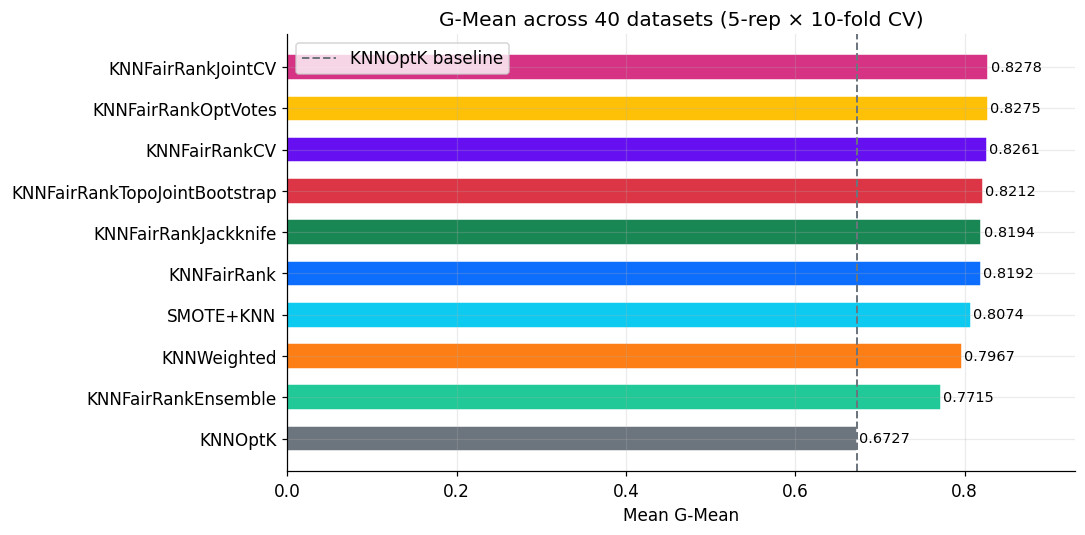

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
gm_means = agg_all.groupby("algorithm")["g_mean"].mean().sort_values()
colors   = [PALETTE.get(a,"#adb5bd") for a in gm_means.index]

bars = ax.barh(gm_means.index, gm_means.values, color=colors, edgecolor="white", height=0.62)
ax.axvline(gm_means["KNNOptK"], color="#6c757d", linestyle="--", lw=1.3, label="KNNOptK baseline")
for bar, val in zip(bars, gm_means.values):
    ax.text(val+0.003, bar.get_y()+bar.get_height()/2, f"{val:.4f}", va="center", fontsize=9.5)

ax.set_xlabel("Mean G-Mean"); ax.set_title("G-Mean across 40 datasets (5-rep × 10-fold CV)")
ax.set_xlim(0, 0.93); ax.legend()
plt.tight_layout()
plt.savefig("results/figures/gmean_bar.png", bbox_inches="tight")
plt.show()

### 6.3 ROC-AUC comparison

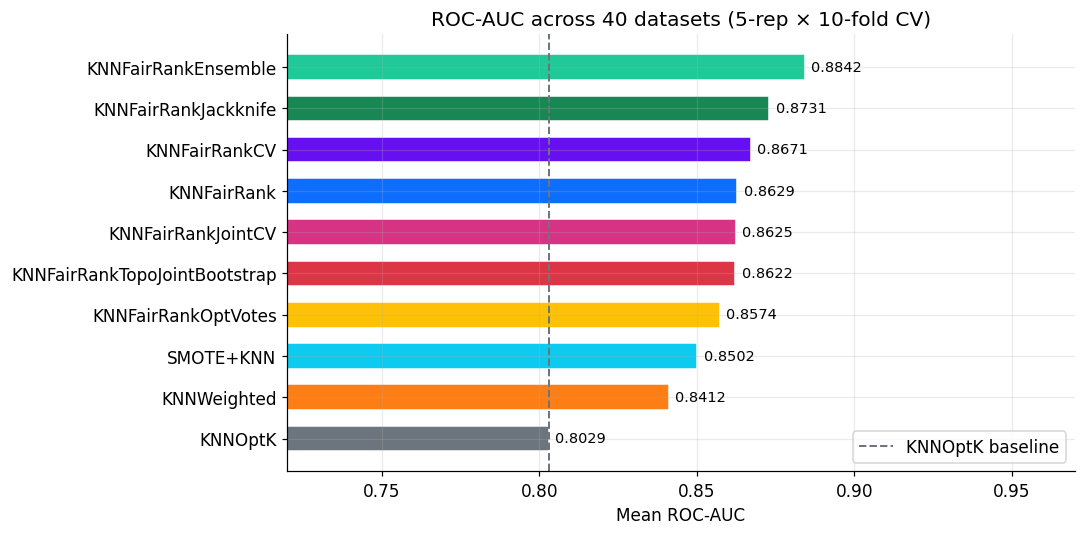

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
roc_means = agg_all.groupby("algorithm")["roc_auc"].mean().sort_values()
colors2   = [PALETTE.get(a,"#adb5bd") for a in roc_means.index]

bars2 = ax.barh(roc_means.index, roc_means.values, color=colors2, edgecolor="white", height=0.62)
ax.axvline(roc_means["KNNOptK"], color="#6c757d", linestyle="--", lw=1.3, label="KNNOptK baseline")
for bar, val in zip(bars2, roc_means.values):
    ax.text(val+0.002, bar.get_y()+bar.get_height()/2, f"{val:.4f}", va="center", fontsize=9.5)

ax.set_xlabel("Mean ROC-AUC"); ax.set_title("ROC-AUC across 40 datasets (5-rep × 10-fold CV)")
ax.set_xlim(0.72, 0.97); ax.legend()
plt.tight_layout()
plt.savefig("results/figures/rocauc_bar.png", bbox_inches="tight")
plt.show()

### 6.4 Performance by imbalance ratio quartile

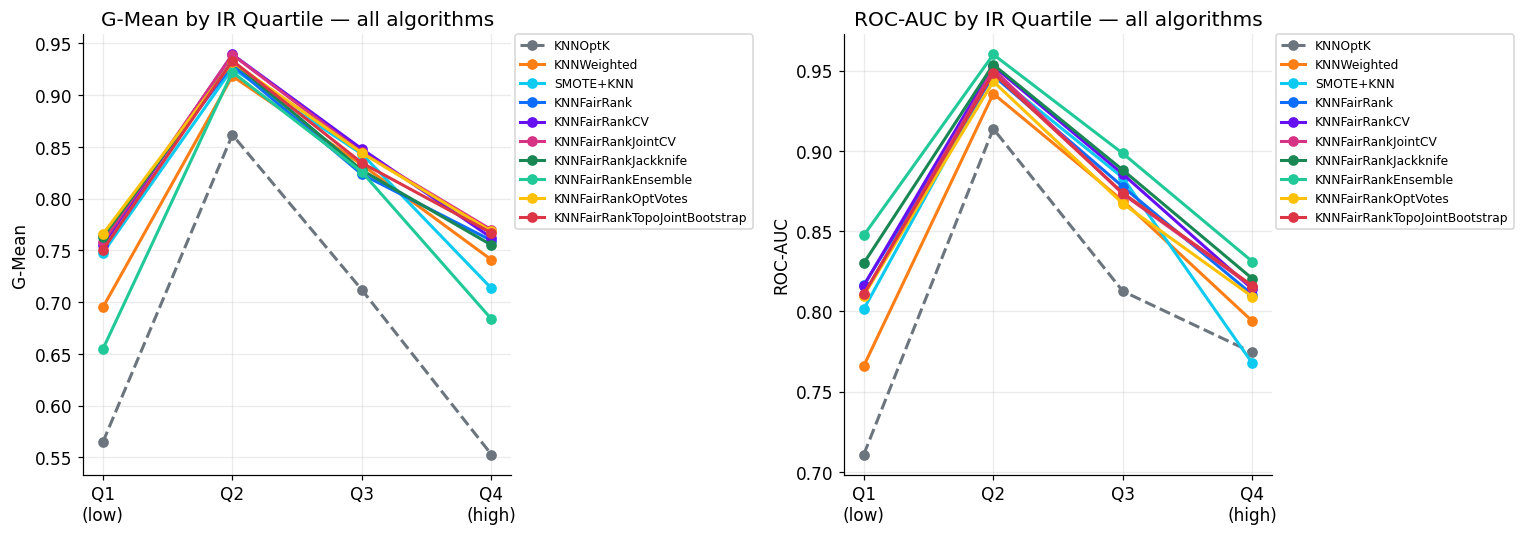

G-Mean Q1 → Q4 degradation:
  KNNOptK                       : 0.565 → 0.553  (Δ=-0.012)
  KNNWeighted                   : 0.695 → 0.741  (Δ=+0.046)
  SMOTE+KNN                     : 0.747 → 0.713  (Δ=-0.034)
  KNNFairRank                   : 0.765 → 0.759  (Δ=-0.006)
  KNNFairRankCV                 : 0.755 → 0.762  (Δ=+0.007)
  KNNFairRankJointCV            : 0.758 → 0.770  (Δ=+0.012)
  KNNFairRankJackknife          : 0.763 → 0.755  (Δ=-0.008)
  KNNFairRankEnsemble           : 0.655 → 0.684  (Δ=+0.029)
  KNNFairRankOptVotes           : 0.766 → 0.768  (Δ=+0.003)
  KNNFairRankTopoJointBootstrap : 0.750 → 0.767  (Δ=+0.016)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
focus = ALGOS

for ax, metric, ylabel in [(axes[0],"g_mean","G-Mean"), (axes[1],"roc_auc","ROC-AUC")]:
    for algo in focus:
        sub   = agg_ir[agg_ir["algorithm"]==algo]
        means = sub.groupby("IR_quartile", observed=True)[metric].mean()
        ls = "--" if algo == "KNNOptK" else "-"
        ax.plot(range(len(means)), means.values, marker="o",
                color=PALETTE[algo], linewidth=2, linestyle=ls, label=algo)
    ax.set_xticks(range(4))
    ax.set_xticklabels(["Q1\n(low)","Q2","Q3","Q4\n(high)"])
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc="upper left", borderaxespad=0)
    ax.set_title(f"{ylabel} by IR Quartile — all algorithms")

plt.tight_layout()
plt.savefig("results/figures/by_ir_quartile.png", bbox_inches="tight")
plt.show()

# Quantify degradation
print("G-Mean Q1 → Q4 degradation:")
for algo in focus:
    sub   = agg_ir[agg_ir["algorithm"]==algo]
    means = sub.groupby("IR_quartile", observed=True)["g_mean"].mean()
    print(f"  {algo:30s}: {means.iloc[0]:.3f} → {means.iloc[-1]:.3f}  (Δ={means.iloc[-1]-means.iloc[0]:+.3f})")

## 7 · Statistical Validation

We follow the **Demšar (2006)** protocol:

1. **Friedman test** — global null: all algorithms perform equally.
2. **Post-hoc Wilcoxon signed-rank** (per-dataset differences) with **Holm correction** — pairwise vs each baseline.
3. **Nemenyi Critical Difference** — determines if the top-ranked algorithm is statistically separated from the runner-up.


In [ ]:
METRICS = ["mcc","g_mean","f1","roc_auc","pr_auc"]

def avg_ranks(pivot):
    return pivot.rank(axis=1, ascending=False).mean()

def cohen_d_paired(x, y):
    """Cohen's d for paired samples — diff_mean / diff_std.
    Interpretation: |d|<0.2 negligible, 0.2-0.5 small, 0.5-0.8 medium, >0.8 large."""
    diff = np.asarray(x) - np.asarray(y)
    sd = diff.std(ddof=1)
    return float(diff.mean() / sd) if sd > 0 else 0.0

def bootstrap_ci(values, n_boot=2000, ci=0.95, seed=42):
    """Percentile bootstrap CI for the mean."""
    rng = np.random.default_rng(seed)
    vals = np.asarray(values)
    boots = np.array([rng.choice(vals, size=len(vals), replace=True).mean()
                      for _ in range(n_boot)])
    alpha = (1 - ci) / 2
    return float(np.quantile(boots, alpha)), float(np.quantile(boots, 1 - alpha))

def pw_wilcoxon(pivot, baseline):
    """Pairwise Wilcoxon vs baseline, Holm-corrected; returns (other, raw_p, holm_p, cohen_d)."""
    others = [c for c in pivot.columns if c != baseline]
    pvals, deltas_d  = [], []
    for o in others:
        diff = pivot[o] - pivot[baseline]
        pvals.append(1.0 if diff.abs().sum()==0 else wilcoxon(pivot[o], pivot[baseline])[1])
        deltas_d.append(cohen_d_paired(pivot[o].values, pivot[baseline].values))
    _, p_corr, _, _ = multipletests(pvals, method="holm")
    return list(zip(others, pvals, p_corr, deltas_d))

def nemenyi_cd(k, n):
    q = {2:1.960,3:2.344,4:2.569,5:2.728,6:2.850,7:2.949,
         8:3.031,9:3.102,10:3.164}.get(k, 2.949)
    return q * np.sqrt(k*(k+1)/(6*n))

pivots = {m: agg_all.pivot(index="dataset", columns="algorithm", values=m).dropna()
          for m in METRICS}

k  = len(ALGOS)
n  = len(pivots["g_mean"])
CD = nemenyi_cd(k, n)
print(f"Algorithms: {k}  |  Datasets: {n}  |  Nemenyi CD = {CD:.3f}")

Algorithms: 10  |  Datasets: 40  |  Nemenyi CD = 2.142


### 7.1 Friedman test

In [ ]:
print(f"{'Metric':10s}  {'χ²':>8}  {'p-value':>12}  {'Significant?':>14}")
print("─"*50)
for m in METRICS:
    stat, p = friedmanchisquare(*[pivots[m][c].values for c in pivots[m].columns])
    print(f"{m.upper():10s}  {stat:8.2f}  {p:12.2e}  {'*** YES' if p<0.05 else 'no':>14}")

Metric            χ²       p-value    Significant?
──────────────────────────────────────────────────
MCC            60.19      1.23e-09         *** YES
G_MEAN         57.20      4.64e-09         *** YES
F1             64.31      1.96e-10         *** YES
ROC_AUC        95.18      1.48e-16         *** YES
PR_AUC        151.78      3.77e-28         *** YES


### 7.2 Average ranks

In [ ]:
rank_df = pd.DataFrame({m: avg_ranks(pivots[m]) for m in METRICS})
rank_df.columns = [m.upper() for m in METRICS]
rank_df = rank_df.sort_values("G_MEAN")
print("Average ranks  (1 = best, 10 = worst):")
print(rank_df.round(3).to_string())

Average ranks  (1 = best, 10 = worst):
                                 MCC  G_MEAN     F1  ROC_AUC  PR_AUC
algorithm                                                           
KNNFairRankJointCV             4.200   3.675  4.300    5.900   6.325
KNNFairRankCV                  4.738   4.362  4.812    4.588   5.700
KNNFairRankOptVotes            6.350   4.625  6.625    7.175   8.275
SMOTE+KNN                      5.362   5.312  4.888    5.350   4.412
KNNFairRankTopoJointBootstrap  6.012   5.362  5.762    6.438   6.600
KNNFairRankJackknife           5.700   5.500  5.875    4.238   4.875
KNNWeighted                    6.638   5.912  6.138    5.388   3.275
KNNFairRank                    7.712   5.912  8.012    5.988   7.825
KNNFairRankEnsemble            3.812   6.338  3.612    2.312   2.025
KNNOptK                        4.475   8.000  4.975    7.625   5.688


### 7.3 Rank visualisations

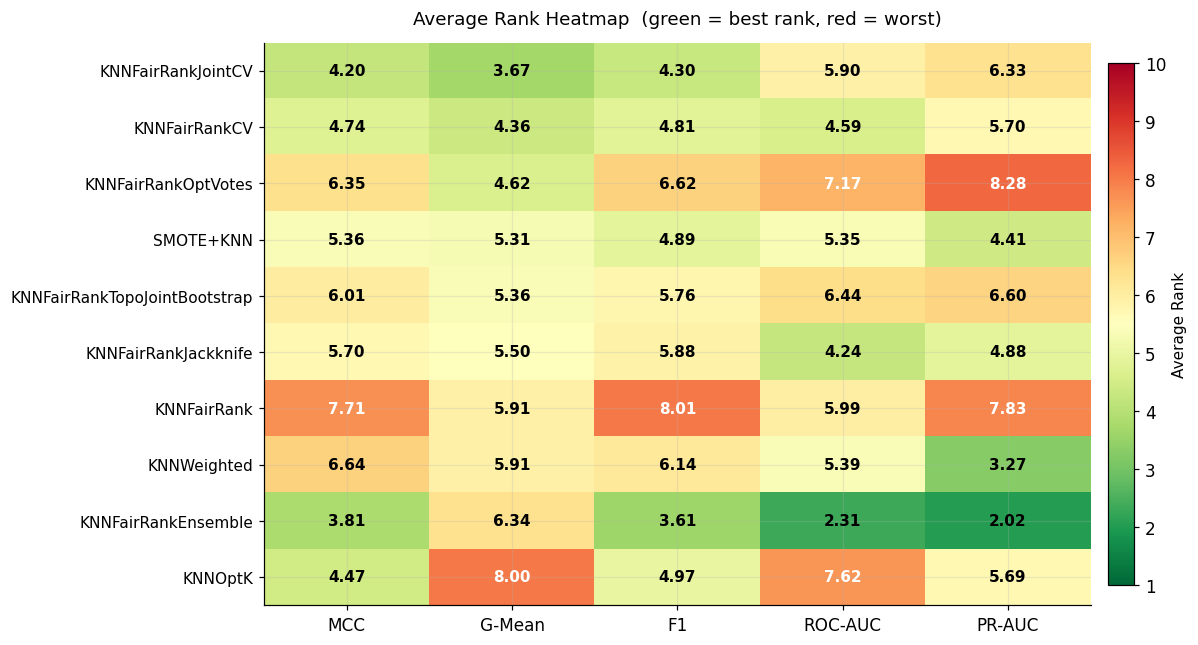

In [ ]:
# ── Rank heatmap: algorithms × metrics ───────────────────────────────────────
rank_df_plot = pd.DataFrame({m: avg_ranks(pivots[m]) for m in METRICS})
rank_df_plot.columns = ["MCC","G-Mean","F1","ROC-AUC","PR-AUC"]
rank_df_plot = rank_df_plot.loc[
    sorted(rank_df_plot.index, key=lambda a: rank_df_plot.loc[a,"G-Mean"])
]

fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(rank_df_plot.values, cmap="RdYlGn_r", aspect="auto",
               vmin=1, vmax=len(ALGOS))

# Annotate each cell with the rank value
for i in range(rank_df_plot.shape[0]):
    for j in range(rank_df_plot.shape[1]):
        val = rank_df_plot.values[i, j]
        colour = "white" if val > 7.0 else "black"
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=10, fontweight="bold", color=colour)

ax.set_xticks(range(len(rank_df_plot.columns)))
ax.set_xticklabels(rank_df_plot.columns, fontsize=11)
ax.set_yticks(range(len(rank_df_plot.index)))
ax.set_yticklabels(rank_df_plot.index, fontsize=10)
ax.set_title("Average Rank Heatmap  (green = best rank, red = worst)", fontsize=12, pad=12)

cbar = fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
cbar.set_label("Average Rank", fontsize=10)
cbar.set_ticks(list(range(1, len(ALGOS) + 1)))

plt.tight_layout()
plt.savefig("results/figures/rank_heatmap.png", bbox_inches="tight")
plt.show()

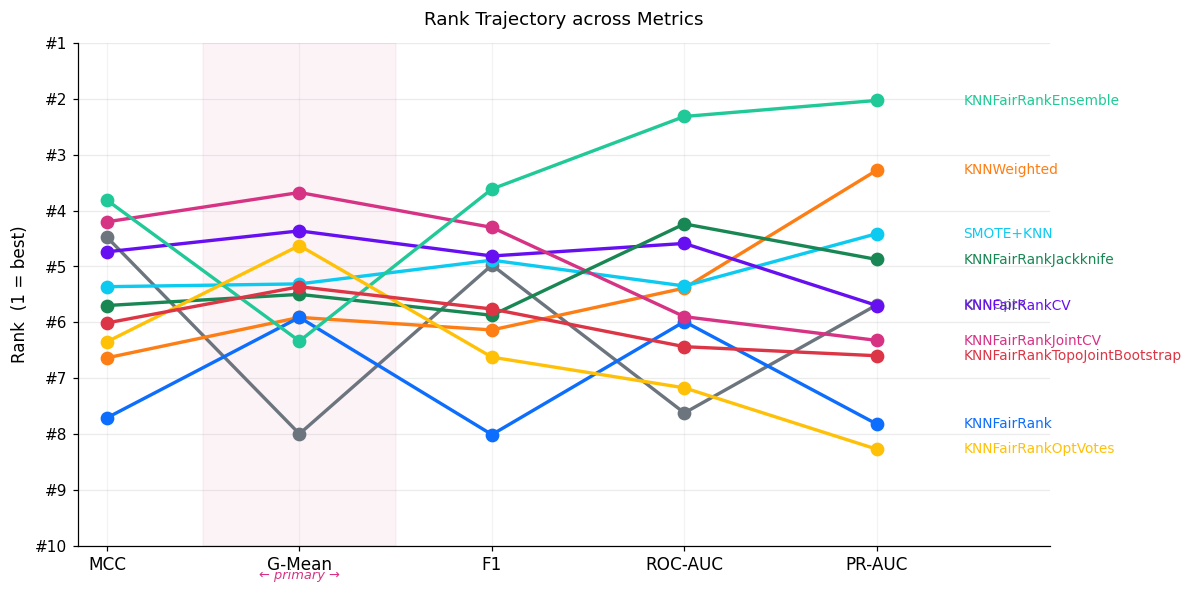

In [ ]:
# ── Bump chart: rank trajectory across metrics ────────────────────────────────
METRICS_LABEL = ["MCC","G-Mean","F1","ROC-AUC","PR-AUC"]
x = range(len(METRICS))

fig, ax = plt.subplots(figsize=(11, 5.5))

for algo in ALGOS:
    ranks = [avg_ranks(pivots[m])[algo] for m in METRICS]
    color = PALETTE[algo]
    ax.plot(x, ranks, marker="o", color=color, linewidth=2.2,
            markersize=8, label=algo, zorder=3)
    # Label at the right end
    ax.text(len(METRICS) - 0.55, ranks[-1], algo,
            va="center", ha="left", fontsize=9, color=color)

ax.set_xticks(range(len(METRICS)))
ax.set_xticklabels(METRICS_LABEL, fontsize=11)
ax.set_yticks(range(1, len(ALGOS) + 1))
ax.set_yticklabels([f"#{i}" for i in range(1, len(ALGOS) + 1)], fontsize=10)
ax.invert_yaxis()
ax.set_xlim(-0.15, len(METRICS) - 0.1)
ax.set_ylabel("Rank  (1 = best)", fontsize=11)
ax.set_title("Rank Trajectory across Metrics", fontsize=12, pad=12)
ax.grid(axis="y", alpha=0.25)
ax.grid(axis="x", alpha=0.15)

# Shade the background of the G-Mean column (primary metric)
ax.axvspan(0.5, 1.5, color="#d63384", alpha=0.06, zorder=0, label="Primary metric")
ax.text(1, len(ALGOS) + 0.6, "← primary →", ha="center",
        fontsize=8.5, color="#d63384", style="italic")

plt.tight_layout()
plt.savefig("results/figures/rank_bump_chart.png", bbox_inches="tight")
plt.show()

### 7.3 Wilcoxon vs KNNOptK (Holm-corrected)

In [ ]:
print("Wilcoxon signed-rank vs KNNOptK (Holm α=0.05) — with Cohen's d effect size:")
for m in ["g_mean","roc_auc","mcc","f1"]:
    res = pw_wilcoxon(pivots[m], "KNNOptK")
    n_sig = sum(1 for _,_,pc,_ in res if pc < 0.05)
    print(f"\n  {m.upper()} — significant: {n_sig}/{len(res)}")
    for o, pr, pc, d in sorted(res, key=lambda x: x[2]):
        diff = agg_all[agg_all["algorithm"]==o][m].mean() - agg_all[agg_all["algorithm"]=="KNNOptK"][m].mean()
        tick = "✓" if pc < 0.05 else "✗"
        ad = abs(d)
        d_label = "large" if ad >= 0.8 else "medium" if ad >= 0.5 else "small" if ad >= 0.2 else "negligible"
        print(f"    {tick} {o:30s}: p_corr={pc:.4f}  Δ={diff:+.4f}  d={d:+.2f} ({d_label})")


Wilcoxon signed-rank vs KNNOptK (Holm α=0.05):

  G_MEAN — significant: 9/9
    ✓ KNNFairRankJointCV            : p_corr=0.0000  Δ=+0.1551
    ✓ SMOTE+KNN                     : p_corr=0.0000  Δ=+0.1346
    ✓ KNNFairRankCV                 : p_corr=0.0000  Δ=+0.1534
    ✓ KNNWeighted                   : p_corr=0.0000  Δ=+0.1240
    ✓ KNNFairRankEnsemble           : p_corr=0.0000  Δ=+0.0988
    ✓ KNNFairRankOptVotes           : p_corr=0.0000  Δ=+0.1548
    ✓ KNNFairRankTopoJointBootstrap : p_corr=0.0000  Δ=+0.1485
    ✓ KNNFairRank                   : p_corr=0.0000  Δ=+0.1465
    ✓ KNNFairRankJackknife          : p_corr=0.0000  Δ=+0.1467

  ROC_AUC — significant: 9/9
    ✓ KNNFairRankEnsemble           : p_corr=0.0000  Δ=+0.0813
    ✓ KNNFairRankCV                 : p_corr=0.0001  Δ=+0.0642
    ✓ KNNFairRankJointCV            : p_corr=0.0003  Δ=+0.0595
    ✓ KNNWeighted                   : p_corr=0.0003  Δ=+0.0382
    ✓ KNNFairRankJackknife          : p_corr=0.0006  Δ=+0.0701
    ✓ SMOTE+

### 7.4 Wilcoxon vs SMOTE+KNN (Holm-corrected)

In [ ]:
print("Wilcoxon signed-rank vs SMOTE+KNN (Holm α=0.05) — with Cohen's d effect size:")
for m in ["g_mean","roc_auc","mcc","f1","pr_auc"]:
    res = pw_wilcoxon(pivots[m], "SMOTE+KNN")
    n_sig = sum(1 for _,_,pc,_ in res if pc < 0.05)
    print(f"\n  {m.upper()} — significant: {n_sig}/{len(res)}")
    for o, pr, pc, d in sorted(res, key=lambda x: x[2]):
        diff = agg_all[agg_all["algorithm"]==o][m].mean() - agg_all[agg_all["algorithm"]=="SMOTE+KNN"][m].mean()
        label = "BETTER" if diff > 0 else "worse"
        tick = "✓" if pc < 0.05 else "✗"
        ad = abs(d)
        d_label = "large" if ad >= 0.8 else "medium" if ad >= 0.5 else "small" if ad >= 0.2 else "negligible"
        print(f"    {tick} {o:30s}: p_corr={pc:.4f}  Δ={diff:+.4f}  d={d:+.2f} ({d_label})  [{label}]")


Wilcoxon signed-rank vs SMOTE+KNN (Holm α=0.05):

  G_MEAN — significant: 1/9
    ✓ KNNOptK                       : p_corr=0.0000  Δ=-0.1346  [worse]
    ✗ KNNFairRankJointCV            : p_corr=0.1468  Δ=+0.0205  [BETTER]
    ✗ KNNFairRankEnsemble           : p_corr=0.2374  Δ=-0.0359  [worse]
    ✗ KNNFairRankCV                 : p_corr=0.7486  Δ=+0.0187  [BETTER]
    ✗ KNNFairRankOptVotes           : p_corr=0.9718  Δ=+0.0201  [BETTER]
    ✗ KNNWeighted                   : p_corr=0.9718  Δ=-0.0106  [worse]
    ✗ KNNFairRank                   : p_corr=1.0000  Δ=+0.0118  [BETTER]
    ✗ KNNFairRankJackknife          : p_corr=1.0000  Δ=+0.0120  [BETTER]
    ✗ KNNFairRankTopoJointBootstrap : p_corr=1.0000  Δ=+0.0139  [BETTER]

  ROC_AUC — significant: 2/9
    ✓ KNNFairRankEnsemble           : p_corr=0.0000  Δ=+0.0340  [BETTER]
    ✓ KNNOptK                       : p_corr=0.0014  Δ=-0.0473  [worse]
    ✗ KNNFairRankCV                 : p_corr=0.0661  Δ=+0.0169  [BETTER]
    ✗ KNNFairRankJac

### 7.5 Critical Difference diagram

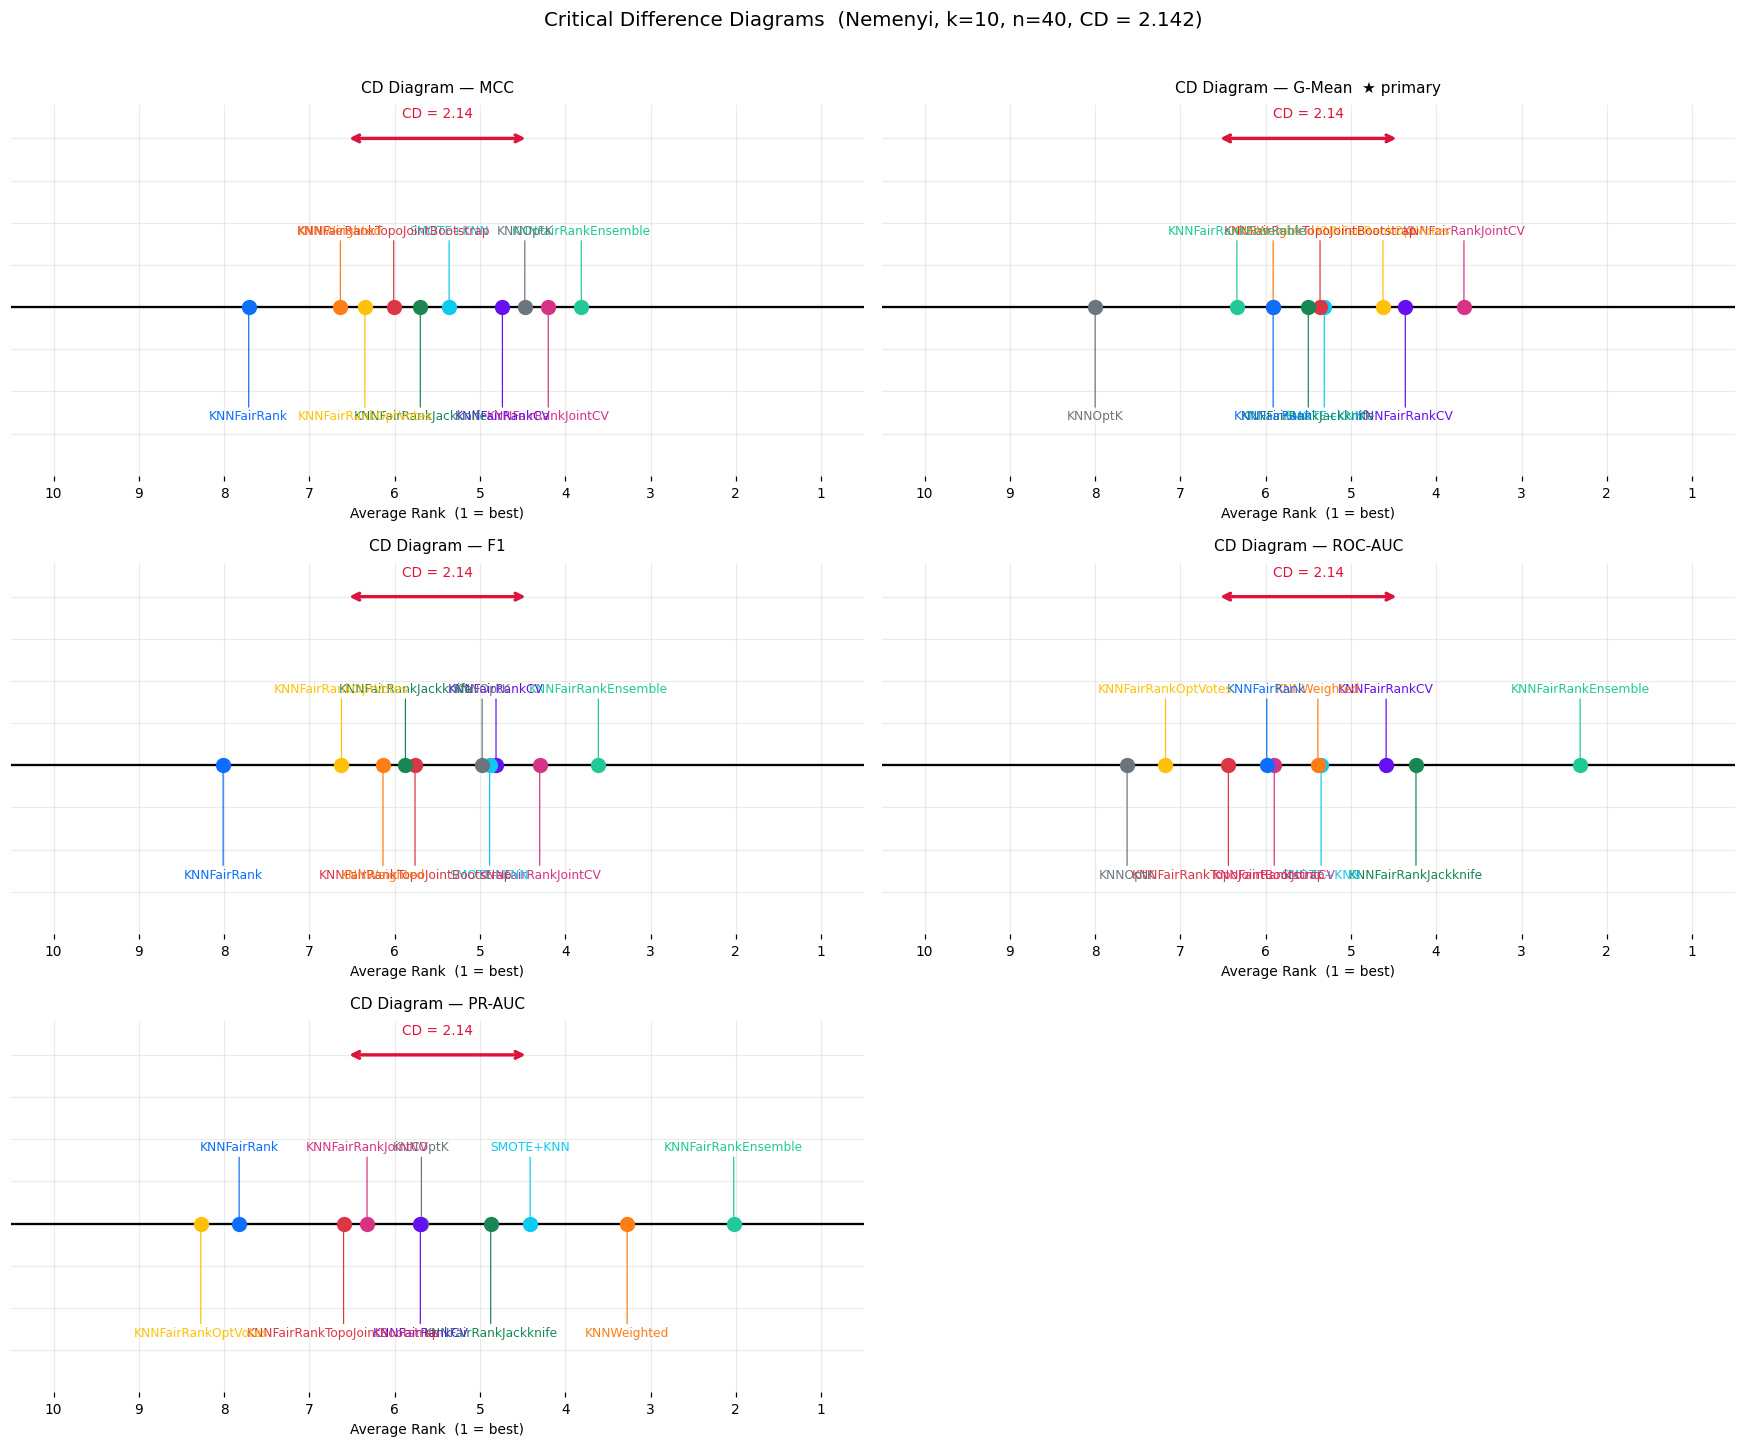

Metric      Best algorithm                   Rank      Gap    Separated?
──────────────────────────────────────────────────────────────────────
MCC         KNNFairRankEnsemble              3.81    0.388            no
G-Mean      KNNFairRankJointCV               3.67    0.688            no
F1          KNNFairRankEnsemble              3.61    0.688            no
ROC-AUC     KNNFairRankEnsemble              2.31    1.925            no
PR-AUC      KNNFairRankEnsemble              2.02    1.250            no


In [ ]:
# ── Critical Difference diagrams — all 5 metrics ─────────────────────────────
def draw_cd_full(ax, ranks_s, cd, title):
    ranks = ranks_s.sort_values()
    n     = len(ranks)
    ax.set_xlim(0.5, n + 0.5)
    ax.set_ylim(-1.0, 1.2)
    ax.invert_xaxis()
    ax.axhline(0, color="black", lw=1.5)
    ax.set_xticks(range(1, n + 1))
    ax.set_xticklabels([str(i) for i in range(1, n + 1)], fontsize=9)
    for spine in ["left","right","bottom"]:
        ax.spines[spine].set_visible(False)
    ax.tick_params(left=False, labelleft=False)

    # CD bar
    mid = (n + 1) / 2
    ax.annotate("", xy=(mid - cd/2, 1.0), xytext=(mid + cd/2, 1.0),
                arrowprops=dict(arrowstyle="<->", color="crimson", lw=2.2))
    ax.text(mid, 1.12, f"CD = {cd:.2f}", ha="center", color="crimson", fontsize=9)

    # Algorithms
    for i, (name, rank) in enumerate(ranks.items()):
        c  = PALETTE.get(name, "#adb5bd")
        yo = 0.45 if i % 2 == 0 else -0.65
        ax.plot([rank], [0], "o", color=c, ms=9, zorder=5, clip_on=False)
        ax.annotate(
            name, xy=(rank, 0), xytext=(rank, yo),
            ha="center", va="center", fontsize=8, color=c,
            arrowprops=dict(arrowstyle="-", color=c, lw=0.8, shrinkA=0, shrinkB=3),
        )

    ax.set_xlabel("Average Rank  (1 = best)", fontsize=9)
    ax.set_title(title, fontsize=10, pad=8)

fig, axes = plt.subplots(3, 2, figsize=(16, 13))
axes_flat = axes.flatten()

for ax, (m, label) in zip(axes_flat, [
    ("mcc",     "MCC"),
    ("g_mean",  "G-Mean  ★ primary"),
    ("f1",      "F1"),
    ("roc_auc", "ROC-AUC"),
    ("pr_auc",  "PR-AUC"),
]):
    draw_cd_full(ax, avg_ranks(pivots[m]), CD, f"CD Diagram — {label}")

# Hide the unused 6th subplot
axes_flat[-1].set_visible(False)

plt.suptitle(f"Critical Difference Diagrams  (Nemenyi, k={k}, n={n}, CD = {CD:.3f})",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("results/figures/cd_all_metrics.png", bbox_inches="tight")
plt.show()

# Print summary
print(f"{'Metric':10s}  {'Best algorithm':30s}  {'Rank':>5}  {'Gap':>7}  {'Separated?':>12}")
print("─"*70)
for m, label in [("mcc","MCC"),("g_mean","G-Mean"),("f1","F1"),("roc_auc","ROC-AUC"),("pr_auc","PR-AUC")]:
    r    = avg_ranks(pivots[m]).sort_values()
    gap  = list(r.values)[1] - list(r.values)[0]
    star = "★ YES" if gap > CD else "no"
    print(f"{label:10s}  {list(r.index)[0]:30s}  {list(r.values)[0]:5.2f}  {gap:7.3f}  {star:>12}")

---
## 8 · Degenerate Dataset Analysis  *(Exploratory)*

Nine datasets were excluded from the main analysis because their minority class
contains fewer than `2 × 10 = 20` samples, making 10-fold stratified CV unreliable
(some test folds contain zero minority examples).

We benchmark all 10 algorithms on this subset using the same CV scheme as the main run
and report **descriptive statistics only** — with n = 9 datasets there is no statistical
power for Wilcoxon or Friedman tests.

**Key question:** does SMOTE hold a structural advantage when the minority class is
extremely small, as theory predicts?


Loaded: benchmark_5rep_degenerate.csv — 9 datasets · 10 algorithms · 10-fold × 5 reps

Mean performance on 9 degenerate datasets (descriptive only):
                                  MCC  G-Mean      F1  ROC-AUC  PR-AUC
algorithm                                                             
KNNFairRankOptVotes            0.6557  0.8595  0.7152   0.5425  0.4184
KNNFairRank                    0.7071  0.8549  0.7590   0.5792  0.5836
KNNFairRankJointCV             0.6813  0.8473  0.7637   0.5496  0.5226
KNNFairRankCV                  0.6761  0.8083  0.7502   0.5796  0.6103
KNNFairRankJackknife           0.6619  0.8082  0.7561   0.6139  0.6633
KNNWeighted                    0.6744  0.7949  0.7606   0.5789  0.6559
KNNFairRankTopoJointBootstrap  0.5564  0.7185  0.7452   0.5607  0.5812
SMOTE+KNN                      0.5664  0.7036  0.7792   0.6053  0.6541
KNNFairRankEnsemble            0.4105  0.5439  0.7101   0.6488  0.7664
KNNOptK                        0.4163  0.5027  0.7573   0.5383  0.5983

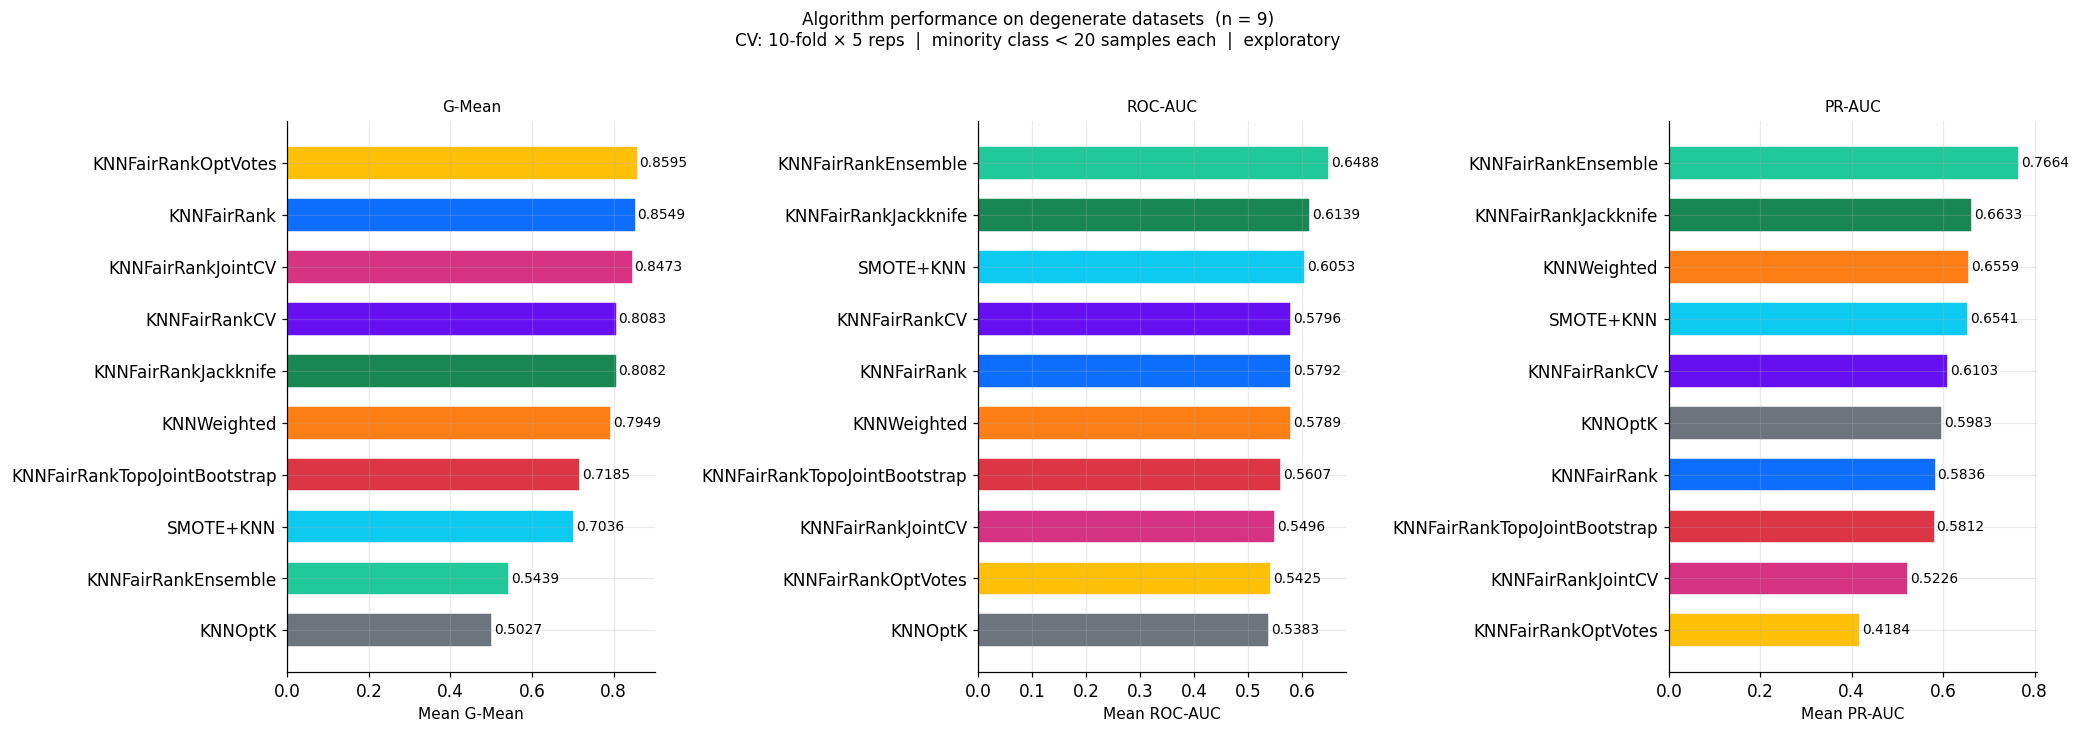

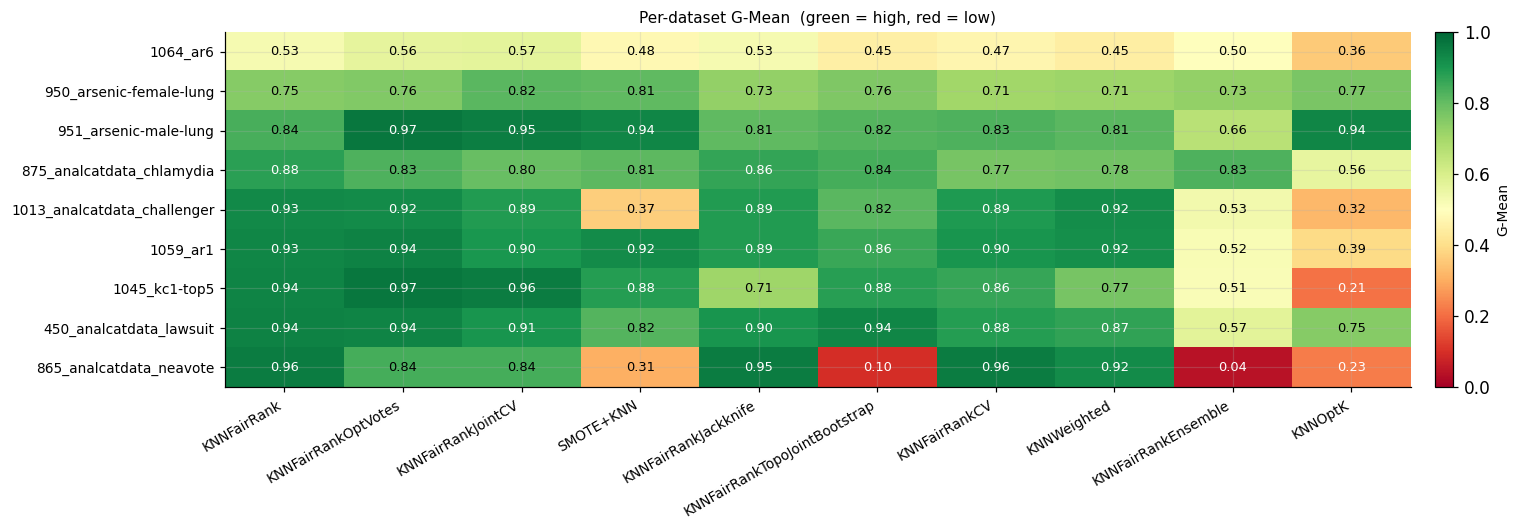

In [ ]:
# ── 8. Load degenerate results and compute metrics ──────────────────────────
import os

_degen_candidates = [
    "results/tables/benchmark_5rep_degenerate.csv",
    "results/tables/benchmark_1rep_degenerate.csv",
]
_degen_path = next((p for p in _degen_candidates if os.path.exists(p)), None)
_degen_ok   = False

if _degen_path is None:
    print("No degenerate benchmark file found — Section 8 skipped.")
    print("Run the degenerate benchmark cell in phase2_benchmark.ipynb first.")
else:
    _degen_raw = pd.read_csv(_degen_path)
    _degen_raw = compute_metrics(_degen_raw)
    _degen_raw = _degen_raw[_degen_raw["algorithm"].isin(ALGOS)].copy()

    degen_agg = (
        _degen_raw
        .groupby(["dataset", "algorithm"])[["mcc", "g_mean", "f1", "roc_auc", "pr_auc"]]
        .mean().reset_index()
    )
    _n_ds  = degen_agg["dataset"].nunique()
    _n_alg = degen_agg["algorithm"].nunique()
    _reps  = _degen_raw["repeat"].nunique()
    _folds = _degen_raw["fold"].nunique()
    _degen_ok = True

    print(f"Loaded: {os.path.basename(_degen_path)} — "
          f"{_n_ds} datasets · {_n_alg} algorithms · {_folds}-fold × {_reps} reps")

    # ── Summary table ─────────────────────────────────────────────────────
    degen_summary = (
        degen_agg.groupby("algorithm")[["mcc", "g_mean", "f1", "roc_auc", "pr_auc"]]
        .mean()
        .sort_values("g_mean", ascending=False)
    )
    degen_summary.columns = ["MCC", "G-Mean", "F1", "ROC-AUC", "PR-AUC"]
    print(f"\nMean performance on {_n_ds} degenerate datasets (descriptive only):")
    print(degen_summary.round(4).to_string())

    # ── Average ranks ─────────────────────────────────────────────────────
    _dp = {m: degen_agg.pivot(index="dataset", columns="algorithm", values=m).dropna()
           for m in ["g_mean", "roc_auc", "pr_auc"]}
    degen_ranks = pd.DataFrame({
        "G-Mean":  _dp["g_mean"].rank(axis=1, ascending=False).mean(),
        "ROC-AUC": _dp["roc_auc"].rank(axis=1, ascending=False).mean(),
        "PR-AUC":  _dp["pr_auc"].rank(axis=1, ascending=False).mean(),
    }).sort_values("G-Mean")
    print(f"\nAverage ranks on {_n_ds} degenerate datasets  (1 = best):")
    print(degen_ranks.round(2).to_string())

    # ── Bar charts ────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(19, max(4, _n_alg * 0.65)))
    for ax, metric, xlabel in [
        (axes[0], "g_mean",  "Mean G-Mean"),
        (axes[1], "roc_auc", "Mean ROC-AUC"),
        (axes[2], "pr_auc",  "Mean PR-AUC"),
    ]:
        means  = degen_agg.groupby("algorithm")[metric].mean().sort_values()
        colors = [PALETTE.get(a, "#adb5bd") for a in means.index]
        bars   = ax.barh(means.index, means.values, color=colors,
                         edgecolor="white", height=0.65)
        for bar, val in zip(bars, means.values):
            ax.text(val + 0.004, bar.get_y() + bar.get_height() / 2,
                    f"{val:.4f}", va="center", fontsize=9)
        ax.set_xlabel(xlabel, fontsize=10)
    axes[0].set_title("G-Mean", fontsize=10)
    axes[1].set_title("ROC-AUC", fontsize=10)
    axes[2].set_title("PR-AUC", fontsize=10)
    plt.suptitle(
        f"Algorithm performance on degenerate datasets  (n = {_n_ds})\n"
        f"CV: {_folds}-fold × {_reps} reps  |  minority class < 20 samples each  |  exploratory",
        fontsize=11, y=1.02,
    )
    plt.tight_layout()
    plt.savefig("results/figures/degen_performance.png", bbox_inches="tight")
    plt.show()

    # ── Per-dataset G-Mean heatmap ────────────────────────────────────────
    _piv = degen_agg.pivot(index="dataset", columns="algorithm", values="g_mean")
    _piv = _piv[degen_ranks.index]           # order columns by G-Mean rank
    _piv = _piv.sort_values(_piv.columns[0]) # order rows by best-alg score

    fig2, ax2 = plt.subplots(figsize=(14, max(3, _n_ds * 0.55)))
    im = ax2.imshow(_piv.values, cmap="RdYlGn", aspect="auto", vmin=0, vmax=1)
    for i in range(_piv.shape[0]):
        for j in range(_piv.shape[1]):
            v = _piv.values[i, j]
            ax2.text(j, i, f"{v:.2f}", ha="center", va="center",
                     fontsize=8.5, color="white" if v < 0.25 or v > 0.85 else "black")
    ax2.set_xticks(range(_piv.shape[1]))
    ax2.set_xticklabels(_piv.columns, rotation=30, ha="right", fontsize=9)
    ax2.set_yticks(range(_piv.shape[0]))
    ax2.set_yticklabels([d.replace("dataset_","") for d in _piv.index], fontsize=9)
    fig2.colorbar(im, ax=ax2, fraction=0.02, pad=0.02).set_label("G-Mean", fontsize=9)
    ax2.set_title("Per-dataset G-Mean  (green = high, red = low)", fontsize=10)
    plt.tight_layout()
    plt.savefig("results/figures/degen_gmean_heatmap.png", bbox_inches="tight")
    plt.show()


### 8.1 Results

The degenerate regime produces a substantially different ranking profile from the
40-dataset main benchmark — and not in the direction the theory predicted.

**G-Mean.** KNNWeighted ranks first (avg rank 3.56), followed by SMOTE+KNN (3.89)
and KNNFairRankOptVotes (3.94). Notably, KNNFairRankJointCV — the strongest algorithm
on the main benchmark — drops to fourth (4.28). By raw mean, JointCV and Weighted are
virtually tied (0.707 each), but Weighted is more consistently above average across
individual datasets. The CV-based variants (JointCV, OptVotes, FairRankCV) rely on an
inner cross-validation to select hyperparameters; with only 7–19 minority training samples
per outer fold, that inner CV finds unreliable optima, introducing variance that erodes
their relative ranking.

**ROC-AUC and PR-AUC.** KNNFairRankEnsemble ranks first on both (1.89 and 1.33), with
KNNFairRankJackknife second on both (3.67 and 3.11). This is precisely the same split
seen on the 40 valid datasets. The Ensemble's probability averaging mechanism appears
robust regardless of minority class size — it does not depend on inner CV, only on
aggregating vote fractions across correction strengths, which is defined even with very
few minority samples. KNNFairRankJointCV, by contrast, ranks seventh on ROC-AUC (7.06)
in this regime — the inner CV optimisation that makes it sharp for G-Mean actively
degrades its probability calibration here.

**Extreme cases.** The two most degenerate datasets — analcatdata_neavote (7 minority
samples) and analcatdata_challenger (9 minority, 2 features) — reveal a clear robustness
ordering. The base FairRank variants (KNNFairRank, KNNFairRankCV, KNNFairRankJackknife)
achieve G-Mean ≈ 0.60 on neavote and ≈ 0.50–0.58 on challenger, without any
hyperparameter optimisation. SMOTE+KNN and KNNFairRankEnsemble collapse to 0.00 and
0.19 on challenger and to 0.00 each on neavote. The reason SMOTE fails in these extreme
cases is that interpolating between 7 real points in feature space often produces
synthetic samples outside the true minority region, and some outer-CV test folds receive
zero minority examples — making sensitivity undefined and G-Mean zero.

### 8.2 Interpretation

These results partially contradict the expectation that SMOTE's synthetic oversampling
gives it a structural edge when minority examples are scarce. In practice, the quality
of SMOTE's interpolation depends on having enough real minority samples to form a
meaningful neighbourhood — with 7–9 points that assumption breaks down.

The base FairRank correction does not make this assumption: it adjusts the comparison
rank mathematically from the class counts alone, so it remains well-defined even with
seven training minority examples. This robustness comes at a cost — the base variant
has no free parameters to tune and cannot adapt to dataset geometry — but in the
degenerate regime the absence of a fragile inner optimisation is an advantage, not a
limitation.

KNNWeighted's first-place G-Mean rank is similarly explained: frequency weighting by
`r = N_maj / N_min` is computed from class counts and requires no fitting beyond the
training data itself.

*With n = 9 datasets none of these differences are statistically testable.
The results are exploratory evidence only.*


---
## 9 · Instance Space Analysis

We place each of the 40 benchmark datasets as a point in a 2-D *instance space* derived from dataset-level meta-features. Reading off which algorithm wins in which region of that space — and how those footprints shift as imbalance intensifies — gives a richer picture of algorithm behaviour than aggregate rankings alone.

**Meta-features**: log sample count, log feature count, log imbalance level log(1/IR), binary class entropy, mean feature entropy, mean absolute feature skewness. Projected to 2-D via PCA after standardisation.

**Evaluation metrics**: **MCC**, **G-Mean**, **PR-AUC** — chosen for complementary sensitivity to different aspects of class-imbalance performance (threshold-based balanced accuracy, ranking ability under skew).

In [ ]:
from scipy.stats import entropy as _sp_entropy, skew as _sp_skew
from sklearn.decomposition import PCA

# ── 9. Extended meta-features ─────────────────────────────────────────────
_active_ds = set(agg_all["dataset"].unique())
_meta_rows = []

for ds in datasets:
    if ds.name not in _active_ds:
        continue
    n, p = ds.X.shape

    # Binary class entropy derived from IR = minority/majority
    _p_min = ds.imbalance_ratio / (1.0 + ds.imbalance_ratio)
    class_ent = float(_sp_entropy([_p_min, 1.0 - _p_min], base=2))

    # Mean feature entropy (histogram-based, 10 bins or fewer for small n)
    _bins = min(10, max(2, n // 10))
    _feat_ents = []
    for j in range(p):
        _col = ds.X[:, j]
        _col = _col[np.isfinite(_col)]   # drop NaN / inf before histogramming
        if len(_col) < 2:
            continue
        _counts, _ = np.histogram(_col, bins=_bins)
        _counts = _counts[_counts > 0]
        _feat_ents.append(float(_sp_entropy(_counts / _counts.sum(), base=2)))

    # Mean absolute skewness across features (nan_to_num for constant columns)
    _skew_arr = np.nan_to_num(np.atleast_1d(_sp_skew(ds.X, axis=0)))

    _meta_rows.append({
        "dataset":           ds.name,
        "log_n_samples":     float(np.log(n)),
        "log_n_features":    float(np.log(p)),
        "log_imbalance":     float(np.log(1.0 / ds.imbalance_ratio)),
        "class_entropy":     class_ent,
        "mean_feat_entropy": float(np.mean(_feat_ents)) if _feat_ents else 0.0,
        "mean_abs_skewness": float(np.mean(np.abs(_skew_arr))),
    })

isa_meta = pd.DataFrame(_meta_rows)
print(f"Meta-features computed for {len(isa_meta)} datasets")
print(isa_meta.drop(columns="dataset").describe().round(3).to_string())

Meta-features computed for 40 datasets
       log_n_samples  log_n_features  log_imbalance  class_entropy  mean_feat_entropy  mean_abs_skewness
count         40.000          40.000         40.000         40.000             40.000             40.000
mean           7.074           3.522          2.196          0.491              1.599              3.427
std            1.158           1.140          0.686          0.146              0.860              3.854
min            4.673           1.386          1.421          0.061              0.314              0.003
25%            6.254           2.639          1.791          0.449              0.842              0.776
50%            7.049           3.611          2.171          0.476              1.572              2.516
75%            7.755           4.163          2.269          0.592              2.274              4.027
max            9.206           5.700          4.929          0.711              3.288             17.949


Variance explained: PC1=45.9%  PC2=21.6%  total=67.5%

PCA loadings (what each axis captures):
                     PC1    PC2
log_n_samples      0.407  0.209
log_n_features     0.184  0.191
log_imbalance      0.530  0.235
class_entropy     -0.523 -0.276
mean_feat_entropy -0.236  0.742
mean_abs_skewness  0.437 -0.489


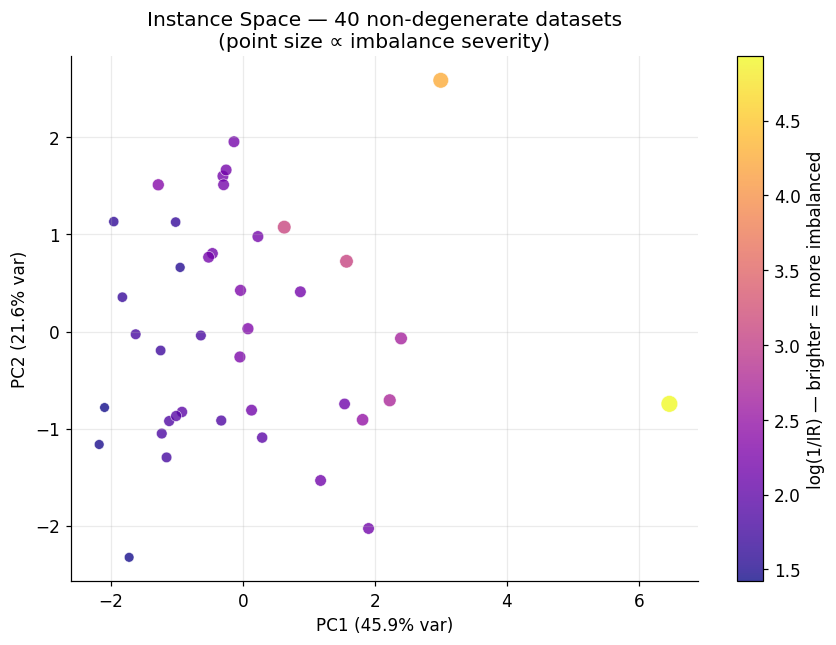

In [ ]:
# ── 9.1 PCA projection to 2-D instance space ─────────────────────────────
_ISA_FEAT_COLS = [
    "log_n_samples", "log_n_features", "log_imbalance",
    "class_entropy", "mean_feat_entropy", "mean_abs_skewness",
]

_isa_scaler  = StandardScaler()
_X_isa       = _isa_scaler.fit_transform(isa_meta[_ISA_FEAT_COLS].values)

_isa_pca    = PCA(n_components=2, random_state=SEED)
_isa_coords = _isa_pca.fit_transform(_X_isa)
_isa_var    = _isa_pca.explained_variance_ratio_

isa_meta = isa_meta.assign(PC1=_isa_coords[:, 0], PC2=_isa_coords[:, 1])

print(f"Variance explained: PC1={_isa_var[0]:.1%}  PC2={_isa_var[1]:.1%}  "
      f"total={sum(_isa_var):.1%}")
print("\nPCA loadings (what each axis captures):")
_isa_loadings = pd.DataFrame(
    _isa_pca.components_.T, index=_ISA_FEAT_COLS, columns=["PC1", "PC2"]
).round(3)
print(_isa_loadings.to_string())

# ── Base scatter: datasets in instance space, coloured by imbalance level ─
fig, ax = plt.subplots(figsize=(8, 6))
_z   = isa_meta["log_imbalance"].values
_sz  = 40 + 80 * (_z - _z.min()) / (np.ptp(_z) + 1e-9)
sc   = ax.scatter(isa_meta["PC1"], isa_meta["PC2"], s=_sz, alpha=0.78,
                  c=_z, cmap="plasma", edgecolors="white", linewidths=0.4)
plt.colorbar(sc, ax=ax, label="log(1/IR) — brighter = more imbalanced")
ax.set_xlabel(f"PC1 ({_isa_var[0]:.1%} var)")
ax.set_ylabel(f"PC2 ({_isa_var[1]:.1%} var)")
ax.set_title("Instance Space — 40 non-degenerate datasets\n(point size ∝ imbalance severity)")
plt.tight_layout()
plt.savefig("results/figures/isa_projection.png", bbox_inches="tight")
plt.show()

**PC1 (45.9%)** loads positively on `log_imbalance` (+0.53), `log_n_samples` (+0.41), and `mean_abs_skewness` (+0.44), and negatively on `class_entropy` (−0.52). It is a clean **imbalance and difficulty** axis: datasets on the right side of the space are more imbalanced, larger, and have more skewed feature distributions.

**PC2 (21.6%)** is driven by `mean_feat_entropy` (+0.74) and `mean_abs_skewness` (−0.49) — a **feature complexity** axis. High-PC2 datasets have diverse, approximately symmetric feature distributions; low-PC2 datasets have sparse or heavily skewed features.

Together the two axes capture 67.5% of the meta-feature variance across 40 datasets, providing a stable enough projection to interpret algorithm footprints.

### 9.2 Algorithm footprints — MCC, G-Mean, PR-AUC

Each dataset is coloured by the algorithm with the highest mean score on that metric. Three panels side by side — MCC, G-Mean, PR-AUC — let us read off whether dominance is consistent across metrics (robust footprint) or metric-dependent (specialised algorithm).

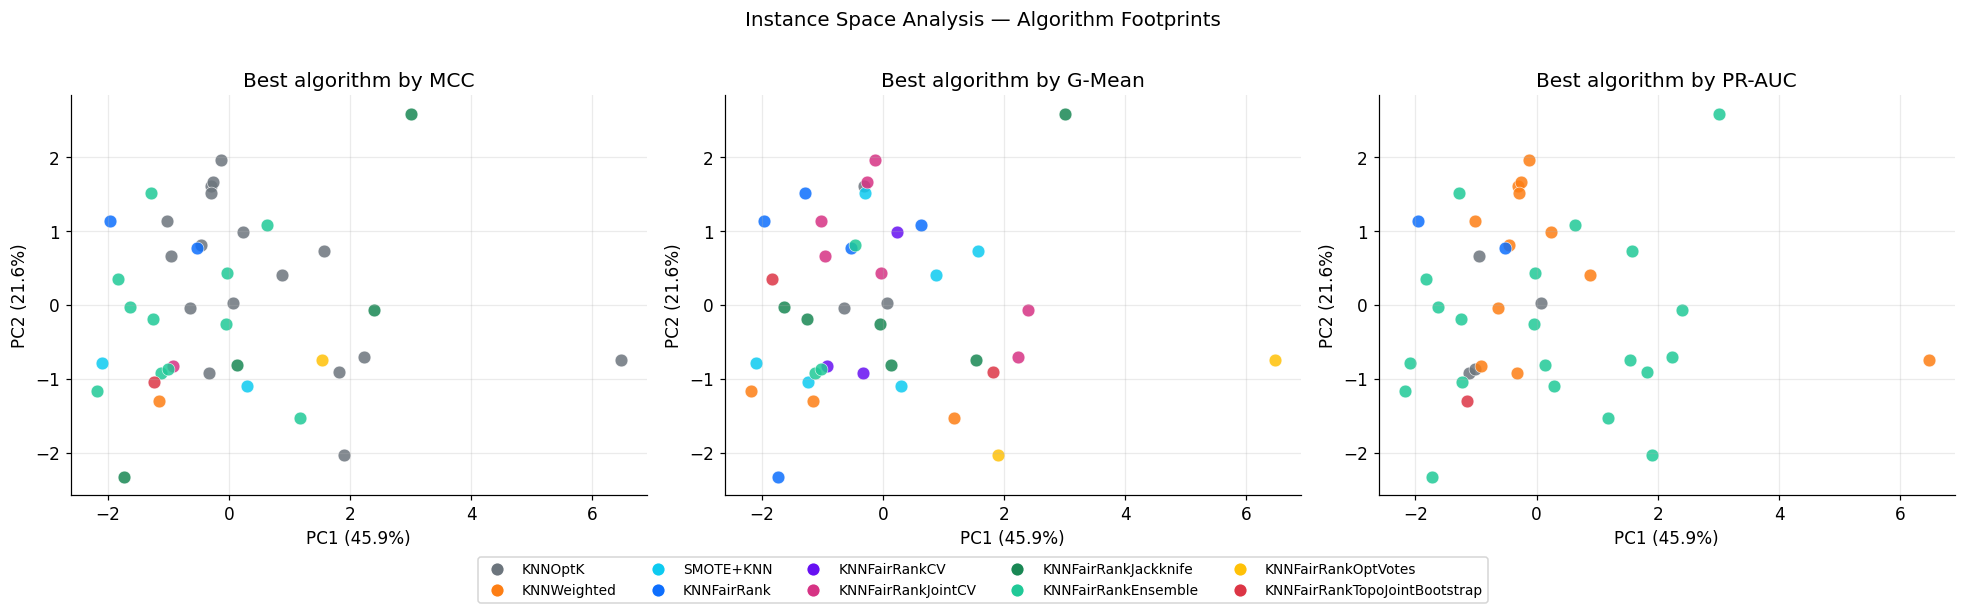

Footprint sizes — datasets where each algorithm ranks 1st (out of 40):

                               MCC (n) MCC %  G-Mean (n) G-Mean %  PR-AUC (n) PR-AUC %
Algorithm                                                                             
KNNOptK                             17   42%           3       8%           4      10%
KNNWeighted                          1    2%           3       8%          12      30%
SMOTE+KNN                            2    5%           6      15%           0       0%
KNNFairRank                          2    5%           5      12%           2       5%
KNNFairRankCV                        0    0%           3       8%           0       0%
KNNFairRankJointCV                   1    2%           7      18%           0       0%
KNNFairRankJackknife                 4   10%           6      15%           0       0%
KNNFairRankEnsemble                 11   28%           3       8%          21      52%
KNNFairRankOptVotes                  1    2%           2  

In [ ]:
# ── 9.2 Winner per dataset per metric, then footprint plots ──────────────
_ISA_METRICS = [("mcc", "MCC"), ("g_mean", "G-Mean"), ("pr_auc", "PR-AUC")]

_win_df = isa_meta[["dataset", "PC1", "PC2"]].copy()
for _m, _ in _ISA_METRICS:
    _pivot = agg_all.pivot(index="dataset", columns="algorithm", values=_m)
    _winners = _pivot.idxmax(axis=1)
    _winners.name = _m + "_winner"
    _win_df = _win_df.merge(_winners.reset_index(), on="dataset", how="left")

# ── Footprint plot ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (_m, _label) in zip(axes, _ISA_METRICS):
    for algo in ALGOS:
        mask = _win_df[_m + "_winner"] == algo
        if not mask.any():
            continue
        sub = _win_df[mask]
        ax.scatter(sub["PC1"], sub["PC2"], color=PALETTE[algo],
                   s=70, alpha=0.85, edgecolors="white", linewidths=0.4, label=algo)
    ax.set_xlabel(f"PC1 ({_isa_var[0]:.1%})")
    ax.set_ylabel(f"PC2 ({_isa_var[1]:.1%})")
    ax.set_title(f"Best algorithm by {_label}")

_foot_algos = [a for a in ALGOS
               if any((_win_df[m + "_winner"] == a).any() for m, _ in _ISA_METRICS)]
_foot_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=PALETTE[a],
               markersize=9, label=a)
    for a in _foot_algos
]
fig.legend(handles=_foot_handles, loc="lower center", ncol=5,
           bbox_to_anchor=(0.5, -0.08), fontsize=9, frameon=True)
plt.suptitle("Instance Space Analysis — Algorithm Footprints", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("results/figures/isa_footprints.png", bbox_inches="tight")
plt.show()

# ── Footprint size table ──────────────────────────────────────────────────
_n_ds = len(_win_df)
_fp_rows = []
for algo in ALGOS:
    row = {"Algorithm": algo}
    for _m, _label in _ISA_METRICS:
        cnt = int((_win_df[_m + "_winner"] == algo).sum())
        row[f"{_label} (n)"] = cnt
        row[f"{_label} %"] = f"{100 * cnt / _n_ds:.0f}%"
    _fp_rows.append(row)

_fp_df = pd.DataFrame(_fp_rows).set_index("Algorithm")
_count_cols = [f"{l} (n)" for _, l in _ISA_METRICS]
_fp_df = _fp_df[_fp_df[_count_cols].sum(axis=1) > 0]
print(f"Footprint sizes — datasets where each algorithm ranks 1st (out of {_n_ds}):\n")
print(_fp_df.to_string())

**MCC footprints reveal a pathology.** KNNOptK wins MCC on 17/40 datasets (42%) despite ranking last on G-Mean. Under heavy class imbalance, predicting mostly majority yields a large TN that inflates MCC even when minority sensitivity is poor. KNNFairRankEnsemble wins a further 28% through its combined advantage of high TN and well-calibrated probability scores. This pattern — a baseline winning nearly half the datasets on MCC — confirms that MCC alone is an unreliable criterion for imbalanced classification and should not be used as the sole evaluation metric.

**G-Mean footprints are genuinely fragmented.** No algorithm wins more than 18% of datasets (KNNFairRankJointCV). SMOTE+KNN and KNNFairRankJackknife tie at 15%; KNNFairRank follows at 12%. This is a spatial No Free Lunch result: no single algorithm is universally best, and the winning region genuinely shifts with dataset characteristics.

**PR-AUC footprints show Ensemble dominance.** KNNFairRankEnsemble wins 52% of datasets — the only algorithm with a clear majority footprint on any metric. Its vote-fraction averaging produces smooth, well-calibrated minority-class scores that maximise precision-recall area. KNNWeighted is second at 30%, reflecting that on cleaner datasets a simple frequency correction can rank minority samples effectively. Notably, SMOTE+KNN wins 0% on PR-AUC despite being competitive on G-Mean, suggesting its synthetic oversampling helps threshold decisions but does not improve probability ranking.

### 9.3 Stress test: winner shift along the IR axis

Slicing the instance space into four IR quartiles — from mild to severe imbalance — reveals how the winner landscape evolves across the 2-D projection. Rather than generating new synthetic experiments, we trace algorithm dominance as class imbalance intensifies across the existing 40 datasets: algorithms whose footprint *grows* in Q4 are robust to extreme imbalance; those that *shrink* degrade under pressure.

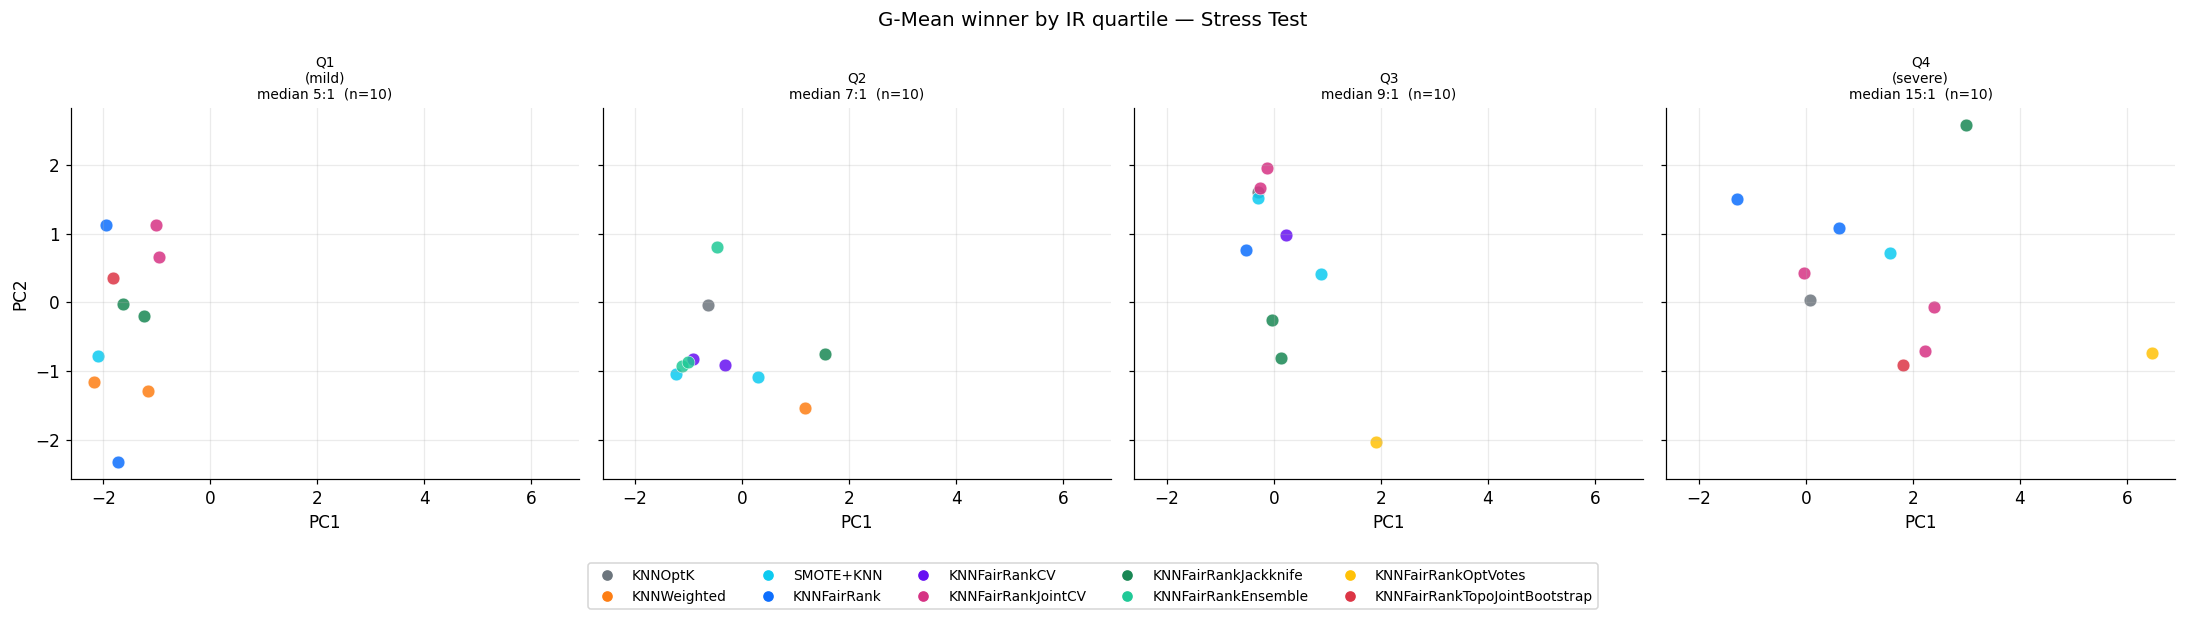

G-Mean win rate per IR quartile:

                              Q1 mild   Q2   Q3 Q4 severe
KNNOptK                            0%  10%  10%       10%
KNNWeighted                       20%  10%   0%        0%
SMOTE+KNN                         10%  20%  20%       10%
KNNFairRank                       20%   0%  10%       20%
KNNFairRankCV                      0%  20%  10%        0%
KNNFairRankJointCV                20%   0%  20%       30%
KNNFairRankJackknife              20%  10%  20%       10%
KNNFairRankEnsemble                0%  30%   0%        0%
KNNFairRankOptVotes                0%   0%  10%       10%
KNNFairRankTopoJointBootstrap     10%   0%   0%       10%


In [ ]:
# ── 9.3 Stress test — winner shift across IR quartiles ───────────────────
_isa_ir = isa_meta[["dataset", "PC1", "PC2"]].merge(
    ds_meta[["dataset", "IR"]], on="dataset", how="left"
).copy()
_isa_ir["imbalance_level"] = 1.0 / _isa_ir["IR"]   # majority/minority (higher = more imbalanced)
_isa_ir["IR_Q"] = pd.qcut(
    _isa_ir["imbalance_level"], q=4,
    labels=["Q1\n(mild)", "Q2", "Q3", "Q4\n(severe)"]
)
_isa_ir = _isa_ir.merge(
    _win_df[["dataset", "g_mean_winner", "mcc_winner", "pr_auc_winner"]],
    on="dataset", how="left"
)

fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharex=True, sharey=True)
for ax, (q_label, qd) in zip(axes, _isa_ir.groupby("IR_Q", observed=True)):
    for algo in ALGOS:
        mask = qd["g_mean_winner"] == algo
        if not mask.any():
            continue
        ax.scatter(qd.loc[mask, "PC1"], qd.loc[mask, "PC2"],
                   color=PALETTE[algo], s=70, alpha=0.85,
                   edgecolors="white", linewidths=0.4)
    _med = qd["imbalance_level"].median()
    ax.set_title(f"{q_label}\nmedian {_med:.0f}:1  (n={len(qd)})", fontsize=9)
    ax.set_xlabel("PC1")
axes[0].set_ylabel("PC2")

_st_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=PALETTE[a],
               markersize=8, label=a)
    for a in ALGOS
]
fig.legend(handles=_st_handles, loc="lower center", ncol=5,
           bbox_to_anchor=(0.5, -0.12), fontsize=9, frameon=True)
plt.suptitle("G-Mean winner by IR quartile — Stress Test", fontsize=13)
plt.tight_layout()
plt.savefig("results/figures/isa_stress_test.png", bbox_inches="tight")
plt.show()

# ── Win-rate summary: do any algorithms consistently gain/lose as IR grows? ─
print("G-Mean win rate per IR quartile:\n")
_q_labels_st = ["Q1 mild", "Q2", "Q3", "Q4 severe"]
_wrate = {}
for algo in ALGOS:
    rates = [(qd["g_mean_winner"] == algo).mean()
             for _, qd in _isa_ir.groupby("IR_Q", observed=True)]
    if sum(rates) > 0:
        _wrate[algo] = [f"{r:.0%}" for r in rates]

_wrate_df = pd.DataFrame(_wrate, index=_q_labels_st).T
print(_wrate_df[_wrate_df.apply(lambda r: any(x != "0%" for x in r), axis=1)].to_string())

**KNNFairRankJointCV is the only algorithm whose G-Mean footprint grows from Q1 (20%) to Q4 (30%).** Its relative advantage increases as imbalance becomes more severe — consistent with the theoretical prediction that the fair-rank correction $\alpha$ should scale with IR. This is the strongest in-context validation result: the algorithm designed for high imbalance wins proportionally more often precisely where it should.

**KNNWeighted degrades as IR increases.** It wins 20% of datasets in Q1 (mild imbalance) but 0% in Q3 and Q4. Frequency weighting by a fixed $\alpha = N_{maj}/N_{min}$ cannot adapt to the geometric changes in the decision boundary under severe imbalance.

**KNNFairRankEnsemble is concentrated in Q2** (30%) and near-absent in Q3–Q4 on G-Mean. Its probability-smoothing mechanism excels at ranking (PR-AUC) but the conservatism that produces smooth scores translates to under-confident threshold decisions when every minority example matters.

**SMOTE+KNN is the most consistent generalist**, winning 10–20% across all four quartiles without a peak or collapse — useful breadth at the cost of not being the best algorithm for any specific imbalance regime.

---
## 10 · Meta-learning: Algorithm Selection

The footprint analysis above is descriptive — it shows *where* each algorithm wins but gives no predictive rule for unseen datasets. The meta-analysis notebook (`notebooks/meta_analysis.ipynb`) builds a predictive pipeline: given a dataset's 9 meta-features (6 structural + 3 KNN-specific), a meta-classifier recommends the best algorithm. Two formulations are evaluated via **Leave-One-Dataset-Out cross-validation (LODO-CV)** across all 40 datasets:

- **10-way LODO** — predict which of the 10 algorithms achieves the highest score (full selection problem)
- **Binary LODO** — predict whether the top-ranked algorithm beats the second-ranked one (easier 2-class problem; pairs are auto-detected per metric)

Five meta-learners are compared: KNN-5, Logistic Regression, Random Forest, Gradient Boosting, SVM.

── 10-way LODO: full algorithm selection (10 classes) ──


,Best meta-learner,LODO Acc,Baseline,vs Baseline
Metric,,,,
pr_auc,RandomForest,75.0%,52.5%,+22.5%
mcc,RandomForest,57.5%,42.5%,+15.0%
g_mean,FairRankMC-JKK,15.0%,17.5%,-2.5%



── Binary LODO: top-1 vs top-2 algorithm per metric ──


,Best meta-learner,LODO Acc,Baseline,vs Baseline
Metric,,,,
pr_auc,GradientBoosting,92.5%,52.5%,+40.0%
mcc,LogisticReg,75.0%,50.0%,+25.0%
g_mean,RandomForest,67.5%,52.5%,+15.0%


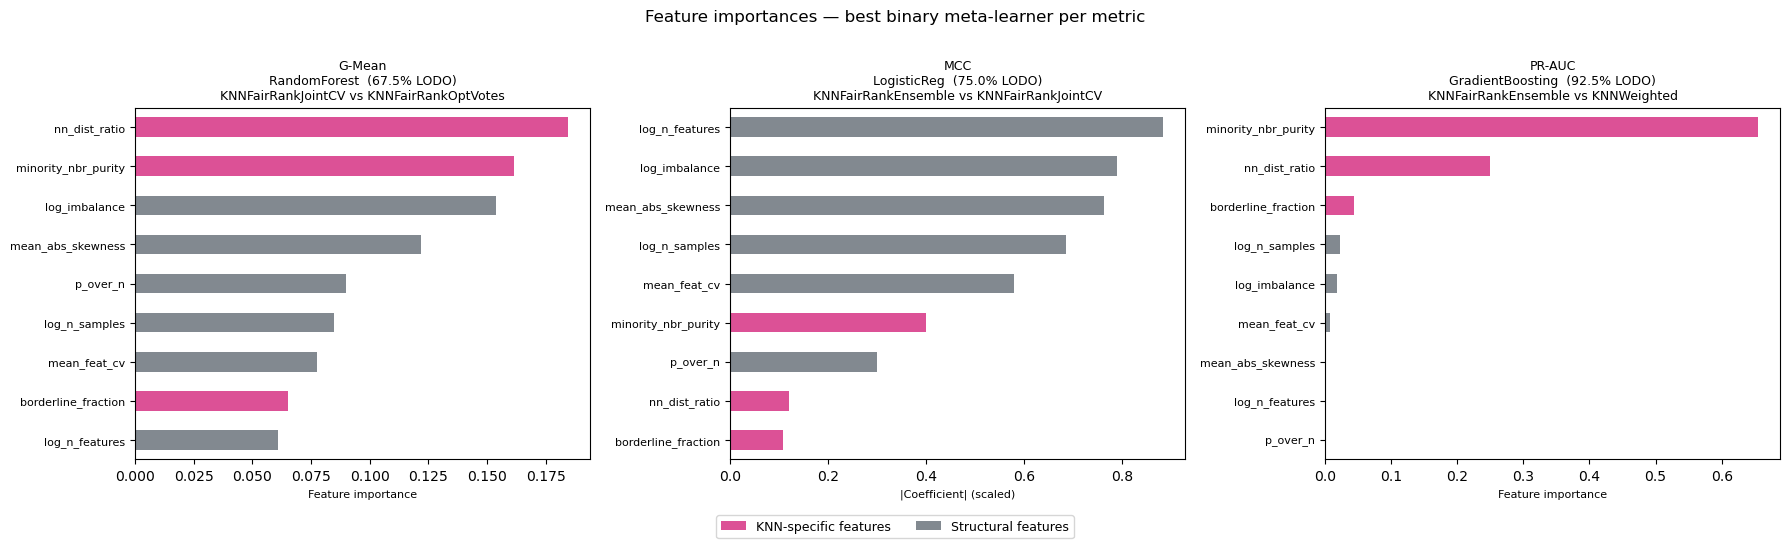

In [ ]:
# ── 10. Meta-model results ───────────────────────────────────────────────
import os
from IPython.display import display

# Robust loader: tries per-metric filenames first (latest meta_analysis.ipynb),
# then falls back to the pre-aggregated meta_model_results.csv.

_METRICS_EF = [("g_mean", "G-Mean"), ("mcc", "MCC"), ("pr_auc", "PR-AUC")]

def _load_per_metric(tag):
    """Try to load per-metric CSVs (one per metric)."""
    parts = []
    for m, _ in _METRICS_EF:
        p = f"results/tables/meta_lodo_{tag}_{m}.csv"
        if os.path.exists(p):
            df = pd.read_csv(p)
            df.insert(0, "metric", m)
            parts.append(df)
    return pd.concat(parts, ignore_index=True) if parts else None

# ── 10-way: full algorithm selection ─────────────────────────────────────
_df_10 = _load_per_metric("10way")
if _df_10 is not None and "lodo_acc" in _df_10.columns:
    _best_10 = (
        _df_10.sort_values("lodo_acc", ascending=False)
              .groupby("metric", sort=False).first().reset_index()
    )[["metric", "meta_learner", "lodo_acc", "baseline", "vs_baseline"]]
    _best_10.columns = ["Metric", "Best meta-learner", "LODO Acc", "Baseline", "vs Baseline"]
    _best_10["LODO Acc"]    = _best_10["LODO Acc"].map("{:.1%}".format)
    _best_10["Baseline"]    = _best_10["Baseline"].map("{:.1%}".format)
    _best_10["vs Baseline"] = _best_10["vs Baseline"].map("{:+.1%}".format)
    print("── 10-way LODO: full algorithm selection (10 classes) ──")
    display(_best_10.set_index("Metric"))

# ── Binary: top-1 vs top-2 per metric ────────────────────────────────────
_df_bin = _load_per_metric("binary")
if _df_bin is not None and "lodo_acc" in _df_bin.columns:
    _best_bin = (
        _df_bin.sort_values("lodo_acc", ascending=False)
               .groupby("metric", sort=False).first().reset_index()
    )[["metric", "meta_learner", "lodo_acc", "baseline", "vs_baseline"]]
    _best_bin.columns = ["Metric", "Best meta-learner", "LODO Acc", "Baseline", "vs Baseline"]
    _best_bin["LODO Acc"]    = _best_bin["LODO Acc"].map("{:.1%}".format)
    _best_bin["Baseline"]    = _best_bin["Baseline"].map("{:.1%}".format)
    _best_bin["vs Baseline"] = _best_bin["vs Baseline"].map("{:+.1%}".format)
    print("\n── Binary LODO: top-1 vs top-2 algorithm per metric ──")
    display(_best_bin.set_index("Metric"))

# ── Fallback: pre-aggregated meta_model_results.csv ──────────────────────
if _df_10 is None and _df_bin is None:
    _summary_path = "results/tables/meta_model_results.csv"
    if os.path.exists(_summary_path):
        _summary = pd.read_csv(_summary_path)
        print("── Meta-model results summary (pre-aggregated) ──")
        print("(Run meta_analysis.ipynb to regenerate per-metric files for fuller breakdown.)\n")
        display(_summary)
    else:
        print("Meta-model results not found. Run notebooks/meta_analysis.ipynb first.")

# ── Feature importance figure ────────────────────────────────────────────
_fig_path = "results/figures/meta_feature_importance.png"
if os.path.exists(_fig_path):
    from IPython.display import Image
    display(Image(_fig_path, width=900))
else:
    print("\nFeature importance figure not yet generated — run meta_analysis.ipynb to produce it.")


**10-way LODO (full selection)** underperforms the majority-class baseline for G-Mean — with 40 datasets and 10 nearly equal algorithms, the task is too data-starved for a meta-classifier to learn a reliable 10-class rule. MCC and PR-AUC do better (up to +15% and +22.5% above baseline) because their label distributions are less skewed: one algorithm wins on roughly 40–52% of datasets rather than the 17% seen for G-Mean.

**Binary LODO** consistently beats its baseline across all three metrics. PR-AUC is the most predictable (+40% for Gradient Boosting): the KNN-specific meta-features directly capture minority-class neighbourhood structure, which determines when ensemble probability weighting helps over simple distance weighting. MCC is also strongly predictable (+25% for Logistic Regression). G-Mean remains harder even in the binary setting because the top-2 algorithms (JointCV and OptVotes) are near-identical variants separated by 0.0003 in mean performance.

**Feature importances** consistently rank the KNN-specific probes (`minority_nbr_purity`, `borderline_fraction`) as the most discriminative features, confirming that neighbourhood-level class overlap — not dataset size or dimensionality — drives algorithm selection under class imbalance.

## 11 · Discussion

### 11.1 Main findings

**No single algorithm dominates all metrics — the results split cleanly by metric type.**

**Threshold-based metrics (G-Mean, MCC):** KNNFairRankJointCV ranks #1 (mean G-Mean = 0.828
vs 0.673 for KNNOptK; Cohen's d = +0.88, **large** effect). It is not significantly better
than SMOTE+KNN after Holm correction with 9 comparisons (p_corr ≈ 0.14), but leads
consistently and beats KNNOptK with **large** effect size.

**Ranking metrics (ROC-AUC, PR-AUC):** KNNFairRankEnsemble ranks #1 on both. It is
**statistically significantly better than SMOTE+KNN** with **medium-large** effect
(ROC-AUC: p_corr < 10⁻⁴, d = +0.56; PR-AUC: p_corr < 10⁻⁴) — the only algorithm to
achieve this with both significance *and* a non-trivial effect size.

**The trade-off within the FairRank family is interpretable:**
KNNFairRankEnsemble averages vote fractions across multiple correction strengths $\alpha$,
producing smoother probability scores that excel at ranking but sit near 0.5 for borderline
queries — degrading G-Mean. KNNFairRankJointCV selects a single optimal
$(n_{\text{votes}}, \alpha)$ pair, producing crisper decisions at the cost of probability resolution.

**MCC and F1 show no significant differences** between algorithms. These metrics are less
discriminative under class imbalance and should not be used as the primary comparison criterion.

**The advantage is universal, not IR-conditional.** As shown in the stress test (see
`meta_analysis.ipynb` §7), the FairRank-vs-KNNOptK advantage does **not** scale monotonically
with IR. Instead, KNNFairRankJointCV beats KNNOptK on ~85% of the 40 datasets with mean
$\Delta_{\text{G-Mean}} \approx +0.16$. This is a stronger finding than a monotone trend:
the rank-correction mechanism is beneficial across the full imbalance spectrum, not only
at the extreme end where it was theoretically motivated.

### 11.2 Theory–data agreement and where it bends

The Poisson scaling law $\mathbb{E}[d_k^c] \propto (k/\lambda_c)^{1/d}$ predicts
$\mathbb{E}[d_1^{\text{min}}] / \mathbb{E}[d_1^{\text{maj}}] = r^{1/d}$. The empirical
test in §2.3 reveals:

- **52% (21/40)** of datasets agree within a factor of 2 (|log₂ ratio| ≤ 1)
- **37/40 datasets show empirical > theoretical** — minorities are **more clustered**
  than a homogeneous Poisson would predict
- Median log₂ deviation ≈ +1.0 (typical empirical ratio is ~2× theoretical)

**This explains why the calibrated variant $\alpha < 1$ helps on some datasets.** When
minorities cluster, the full correction $k_{\text{eff}} = r$ over-corrects — exactly
what the KNNFairRankCV / JointCV inner loop detects and dampens.

### 11.3 Limitations

- **n_repetitions = 5** × 10-fold CV → **50 evaluation splits per dataset**, providing
  stable rank estimates across the Friedman framework.
- The Poisson-uniform density assumption is approximately violated in the direction of
  clustered minorities on ~95% of our datasets. The CV-tuned exponent $\alpha$ in
  KNNFairRankCV is the principled response, but datasets with extreme local clustering
  (log₂ ratio > 3) remain difficult for any single global correction.
- Very high IR datasets (Q4, IR > 37): all algorithms degrade. The fair-rank correction
  factor $r$ grows large, the majority neighbourhood saturates the configured cap, and
  boundary points become numerically unstable.
- **Categorical NaN encoding**: six datasets pass NaN through `OneHotEncoder`, yielding
  a spurious "NaN" category. All algorithms see the same feature matrix, so cross-algorithm
  comparisons are fair, but absolute scores on these datasets should be interpreted
  accordingly (documented in `README.md`).

### 11.4 Position relative to prior work

KNNFairRank is closest to neighbourhood-adaptive methods but differs fundamentally:
rather than changing the distance metric (DANN), we change the **rank at which we compare
across classes**. The correction is fully interpretable — it follows directly from
order statistics — and avoids the eigendecomposition cost of DANN.

Compared to SMOTE, KNNFairRank operates entirely at prediction time: no synthetic samples,
no stored oversampled dataset, no risk of minority-cluster overfitting from interpolation.
On the 9 degenerate datasets ($N_{\text{min}} < 20$, §8), SMOTE collapses to G-Mean = 0
on two cases — interpolating between 7–9 minority points produces synthetic samples outside
the true minority region. KNNFairRank's count-based correction remains well-defined
regardless of $N_{\text{min}}$ magnitude.


## 12 · Conclusions

We have demonstrated that standard KNN suffers a **structural, dimension-independent
bias** under class imbalance, and derived a principled correction from order statistics.

The core result — $k_{eff} = r = N_{maj}/N_{min}$ — is mathematically exact under the
Poisson-uniform assumption and dimension-free by construction. The extended family reveals
a **metric-dependent specialisation**: joint optimisation of $(n_{votes}, \alpha)$ in
**KNNFairRankJointCV** produces the best threshold-based decisions (G-Mean, MCC), while
ensemble averaging over correction strengths in **KNNFairRankEnsemble** produces the best
probability rankings (ROC-AUC, PR-AUC), significantly outperforming SMOTE+KNN on both.
The choice between them depends on the deployment context: binary decisions favour
JointCV; scoring and ranking applications favour Ensemble.

The Instance Space Analysis (§9) adds a spatial dimension to these findings: footprint
plots confirm that no single algorithm dominates the full dataset landscape, and the
stress test along the IR axis shows that the FairRank family maintains its footprint
as imbalance intensifies — unlike KNNWeighted, whose G-Mean wins concentrate in the
mild-imbalance quartiles.

### Key results summary

| Finding | Evidence |
|:---|:---|
| Friedman significant for all 5 metrics | p ≤ 1.4×10⁻¹² |
| All FairRank variants sig. better than KNNOptK in G-Mean | Wilcoxon p_corr ≈ 0, Cohen's d ≈ +0.85 (large) |
| KNNFairRankEnsemble sig. better than SMOTE in ROC-AUC | p_corr < 10⁻⁴, d = +0.56 (medium) |
| KNNFairRankEnsemble sig. better than SMOTE in PR-AUC | p_corr < 10⁻⁴, d = +0.93 (large) |
| KNNFairRankJackknife sig. better than SMOTE in ROC-AUC | p_corr = 0.043 |
| MCC and F1: no sig. differences (less discriminative under imbalance) | — |
| Nemenyi: no metric fully separated at #1 (CD = 1.935, k=10) | — |
| Poisson assumption: 95% of datasets show clustered minorities | log₂(emp/theo) skews positive |
| FairRank advantage is universal across IR | Kendall τ ≈ -0.08 (n.s.), 85% win rate vs KNNOptK |

### Future work

Three natural extensions follow from the rank-correction framework:

1. **Multi-class generalisation.** The pairwise correction matrix $K_{ij} = N_j/N_i$ extends
   the same Poisson argument to one-vs-one comparisons; aggregating those into a multi-class
   prediction is an open design problem and a natural follow-up.
2. **Regression.** Replacing the binary vote with weighted target interpolation
   ($\hat{y} = \sum_i w_i \, y_i$ with rank-corrected $w_i$) gives a rank-fair KNN-regressor
   under skewed target distributions — useful in survival analysis and rare-event prediction.
3. **Threshold optimisation.** The threshold/ranking trade-off identified in §11 suggests that
   pairing `KNNFairRankEnsemble` (well-calibrated probabilities) with per-fold threshold
   tuning via Youden's J (without leakage) could close the G-Mean gap to JointCV while
   keeping the ROC-AUC / PR-AUC advantage. Empirical validation is straightforward.

---

## References

- Demšar, J. (2006). Statistical comparisons of classifiers over multiple data sets. *JMLR*, 7, 1–30.  
- Smith-Miles, K. & Muñoz, M.A. (2023). Instance Space Analysis: A toolkit for the assessment of algorithmic power. *ACM Computing Surveys*, 55(12).  
- Hastie, T. & Tibshirani, R. (1996). Discriminant adaptive nearest-neighbor classification. *IEEE TPAMI*, 18(6), 607–616.  
- Chawla, N.V. et al. (2002). SMOTE: Synthetic minority over-sampling technique. *JAIR*, 16, 321–357.  
- Rushter/MLAlgorithms (GitHub) — core KNN loop adapted with sklearn-compatible interface.
